# LLM Judge Agreement Analysis

Analysis of inter-judge agreement between **GPT-4.1-mini**, **Gemini-2.5-flash-lite**, and **DeepSeek-R1** across two evaluation modes (`3scale` and `3scale_fewshot`).

**Sections:**
1. Setup & Data Loading
2. Judge Score Distributions (Severity Analysis)
3. Overall Agreement Metrics (Krippendorff's α, Fleiss' κ, Cohen's κ)
4. Pairwise Confusion Matrices
5. Agreement Category Analysis (All / 2 / None agree)
6. Model Ranking Comparison (does ordering agree?)
7. Dimension-Level Agreement Breakdown
8. Agreement by Analogy Type
9. Cross-Mode Summary (3scale vs 3scale_fewshot)

In [187]:

# ============================================================
# CELL 1: Setup, Imports, Style Constants
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.metrics import cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

# Optional dependencies
try:
    import krippendorff
    HAS_KRIPPENDORFF = True
except ImportError:
    HAS_KRIPPENDORFF = False
    print("[!] krippendorff not found. Run: pip install krippendorff")

try:
    from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa as sm_fleiss
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("[!] statsmodels not found. Run: pip install statsmodels")

try:
    import pingouin as pg
    HAS_PINGOUIN = True
except ImportError:
    HAS_PINGOUIN = False
    print("[!] pingouin not found. Run: pip install pingouin  (optional, for ICC)")

# ===== THESIS COLOR SCHEME =====
COLORS = {
    'primary':   '#4682B4',  # Steel Blue
    'secondary': '#FF7F50',  # Coral Orange
    'accent1':   '#5A9BD4',  # Light Steel Blue
    'accent2':   '#f7c4ab',  # Light Coral
    'dark':      '#2F5496',  # Dark Steel Blue
    'text':      '#333333',  # Dark Gray
    'light':     '#B0C4DE',  # Light Steel Blue (muted)
}

JUDGE_COLORS = {
    'gpt':     '#4682B4',
    'gemini':  '#FF7F50',
    'deepseek':'#f7c4ab',
}

JUDGE_FULL_NAMES = {
    'gpt':     'GPT-4.1-mini',
    'gemini':  'Gemini-2.5',
    'deepseek':'DeepSeek-R1',
}

MODEL_ABBREV = {
    # LLM generator models
    'deepseek-r1':                   'DeepSeek-R1',
    'gemini-2.5-flash-lite':         'Gemini-2.5',
    'gpt-4.1-mini':                  'GPT-4.1-mini',
    'gpt-4.1-nano':                  'GPT-4.1-nano',
    'gpt-oss-120b':                  'GPT-OSS-120B',
    'gpt-oss-20b':                   'GPT-OSS-20B',
    'grok-4-fast':                   'Grok-4',
    'llama-3.1-405b-instruct':       'Llama-405B',
    'meta-llama-3-1-70b-instruct':   'Llama-70B',
    'meta-llama-3-1-8b-instruct':    'Llama-8B',
    'qwen3-14b':                     'Qwen3-14B',
    'qwen3-32b':                     'Qwen3-32B',
    # Retrieval-based baseline (stage1)
    'retrieval-based':               'Retrieval-Based',
}

JUDGE_MODELS = ['gpt-4.1-mini', 'gemini-2.5-flash-lite', 'deepseek-r1']
JUDGE_SHORTS = ['gpt', 'gemini', 'deepseek']
JUDGE_MAP = dict(zip(JUDGE_MODELS, JUDGE_SHORTS))

DIMENSIONS    = ['coh', 'map', 'exp']
DIM_FULL      = {'coh': 'Coherence', 'map': 'Mapping', 'exp': 'Explanatory'}

# Matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize']    = (12, 8)
plt.rcParams['font.size']         = 11
plt.rcParams['axes.titlesize']    = 14
plt.rcParams['axes.labelsize']    = 12
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.labelweight']  = 'normal'

# Paths
RESULTS_DIR = Path('../results')
JUDGE_DIR   = RESULTS_DIR / 'upgraded_llm'
OUTPUT_DIR  = RESULTS_DIR / 'judge_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"Judge data directory : {JUDGE_DIR}")
print(f"Output directory     : {OUTPUT_DIR}")


[!] krippendorff not found. Run: pip install krippendorff
[!] pingouin not found. Run: pip install pingouin  (optional, for ICC)
Setup complete.
Judge data directory : ..\results\upgraded_llm
Output directory     : ..\results\judge_analysis


In [188]:
# ============================================================
# CELL 2: Data Loading, Merging & Domain Join
# ============================================================

def load_judge_mode(mode_name: str) -> pd.DataFrame:
    """
    Load all 3 judge CSVs for a given mode and merge on record_id.
    Returns a wide DataFrame with columns:
      record_id, source_dataset, target, model, original_mode, analogy_type,
      chosen_analogy, ...
      gpt_coh, gpt_map, gpt_exp, gpt_avg
      gemini_coh, gemini_map, gemini_exp, gemini_avg
      deepseek_coh, deepseek_map, deepseek_exp, deepseek_avg
    """
    META_COLS = ['record_id', 'source_dataset', 'target', 'model',
                 'original_mode', 'analogy_type', 'chosen_analogy',
                 'original_id']

    merged = None
    for judge_full, short in JUDGE_MAP.items():
        fname = JUDGE_DIR / f'upgraded_judge_{mode_name}_{judge_full}.csv'
        df = pd.read_csv(fname)
        df = df[df['status'] == 'success'].copy()
        print(f"  {short:8s}: {len(df):,} success records from {fname.name}")

        df = df.rename(columns={
            'analogy_coherence': f'{short}_coh',
            'mapping_soundness':  f'{short}_map',
            'explanatory_power':  f'{short}_exp',
            'average_score':      f'{short}_avg',
        })

        score_cols = ['record_id', f'{short}_coh', f'{short}_map',
                      f'{short}_exp', f'{short}_avg']

        if merged is None:
            available_meta = [c for c in META_COLS if c in df.columns]
            merged = df[available_meta + score_cols[1:]].copy()
        else:
            merged = merged.merge(df[score_cols], on='record_id', how='inner')

    print(f"  => Merged: {len(merged):,} records with scores from all 3 judges\n")
    return merged

print("Loading 3scale mode...")
df_3scale = load_judge_mode('3scale')

print("Loading 3scale_fewshot mode...")
df_fewshot = load_judge_mode('3scale_fewshot')

# ── Join target domain from SCAR ────────────────────────────────────────────
SCAR_PATH = Path('../data/SCAR_cleaned_manually.csv')
if SCAR_PATH.exists():
    scar = pd.read_csv(SCAR_PATH)
    # Normalise column names (some versions use 'system_a' vs 'System_A')
    scar.columns = scar.columns.str.strip().str.lower()
    scar = (scar[['system_a', 'system_a_domain']]
            .drop_duplicates('system_a')
            .rename(columns={'system_a': 'target', 'system_a_domain': 'target_domain'}))
    df_3scale  = df_3scale.merge(scar,  on='target', how='left')
    df_fewshot = df_fewshot.merge(scar, on='target', how='left')
    cov_3s = df_3scale['target_domain'].notna().mean() * 100
    cov_fs = df_fewshot['target_domain'].notna().mean() * 100
    print(f"Domain coverage — 3scale: {cov_3s:.1f}%  |  fewshot: {cov_fs:.1f}%")
    print(f"Domains found: {sorted(df_3scale['target_domain'].dropna().unique())}")
else:
    print(f"[!] SCAR file not found at {SCAR_PATH}. 'target_domain' will be missing.")
    df_3scale['target_domain']  = np.nan
    df_fewshot['target_domain'] = np.nan

print(f"\n3scale    : {len(df_3scale):,} rows")
print(f"3scale_fs : {len(df_fewshot):,} rows")
print(f"\nGenerator models  : {sorted(df_3scale['model'].unique())}")
print(f"Analogy types     : {sorted(df_3scale['analogy_type'].unique())}")
print(f"Source datasets   : {sorted(df_3scale['source_dataset'].unique())}")
print(f"Retrieval modes   : {sorted(df_3scale['original_mode'].dropna().unique())}")

Loading 3scale mode...
  gpt     : 25,159 success records from upgraded_judge_3scale_gpt-4.1-mini.csv
  gemini  : 25,159 success records from upgraded_judge_3scale_gemini-2.5-flash-lite.csv
  deepseek: 25,158 success records from upgraded_judge_3scale_deepseek-r1.csv
  => Merged: 25,158 records with scores from all 3 judges

Loading 3scale_fewshot mode...
  gpt     : 25,159 success records from upgraded_judge_3scale_fewshot_gpt-4.1-mini.csv
  gemini  : 25,159 success records from upgraded_judge_3scale_fewshot_gemini-2.5-flash-lite.csv
  deepseek: 25,159 success records from upgraded_judge_3scale_fewshot_deepseek-r1.csv
  => Merged: 25,159 records with scores from all 3 judges

[!] SCAR file not found at ..\data\SCAR_cleaned_manually.csv. 'target_domain' will be missing.

3scale    : 25,158 rows
3scale_fs : 25,159 rows

Generator models  : ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano', 'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct', 'me

---
## Section 1: Judge Score Distributions (Severity Analysis)

> **Research question:** Do the three judges have similar scoring tendencies, or is one systematically more lenient/harsh?

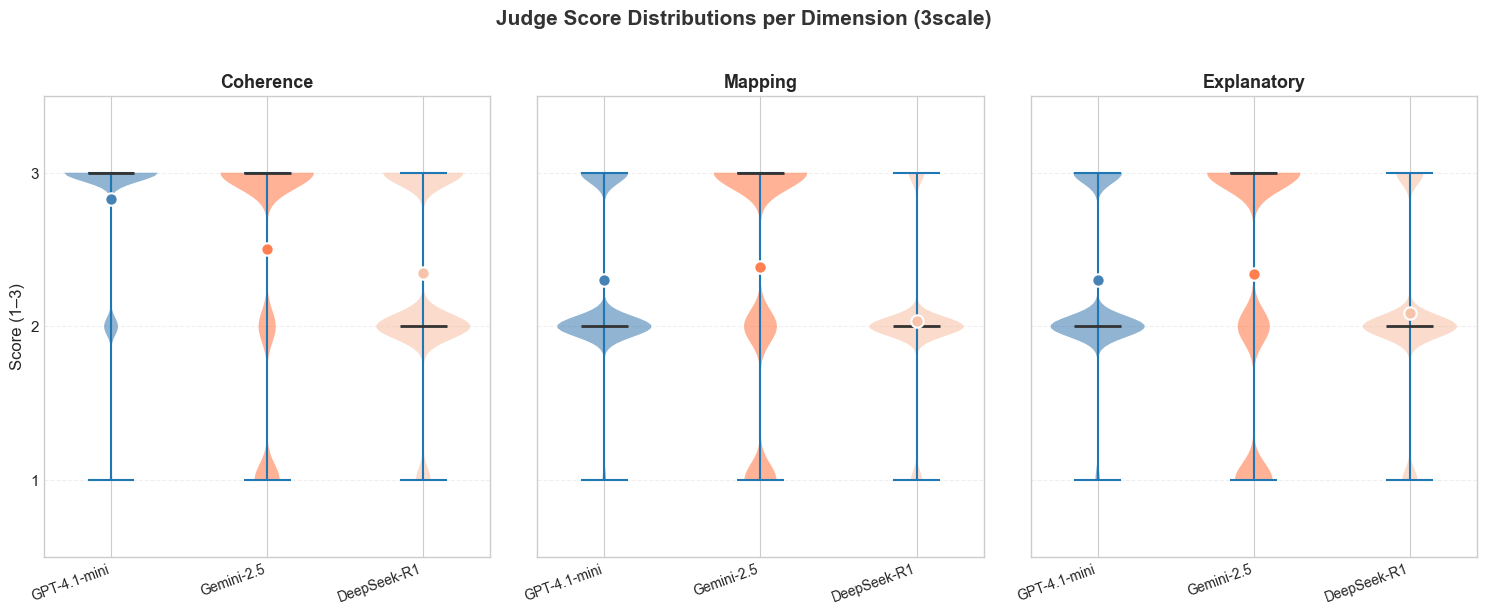

Saved: severity_violin_3scale.png


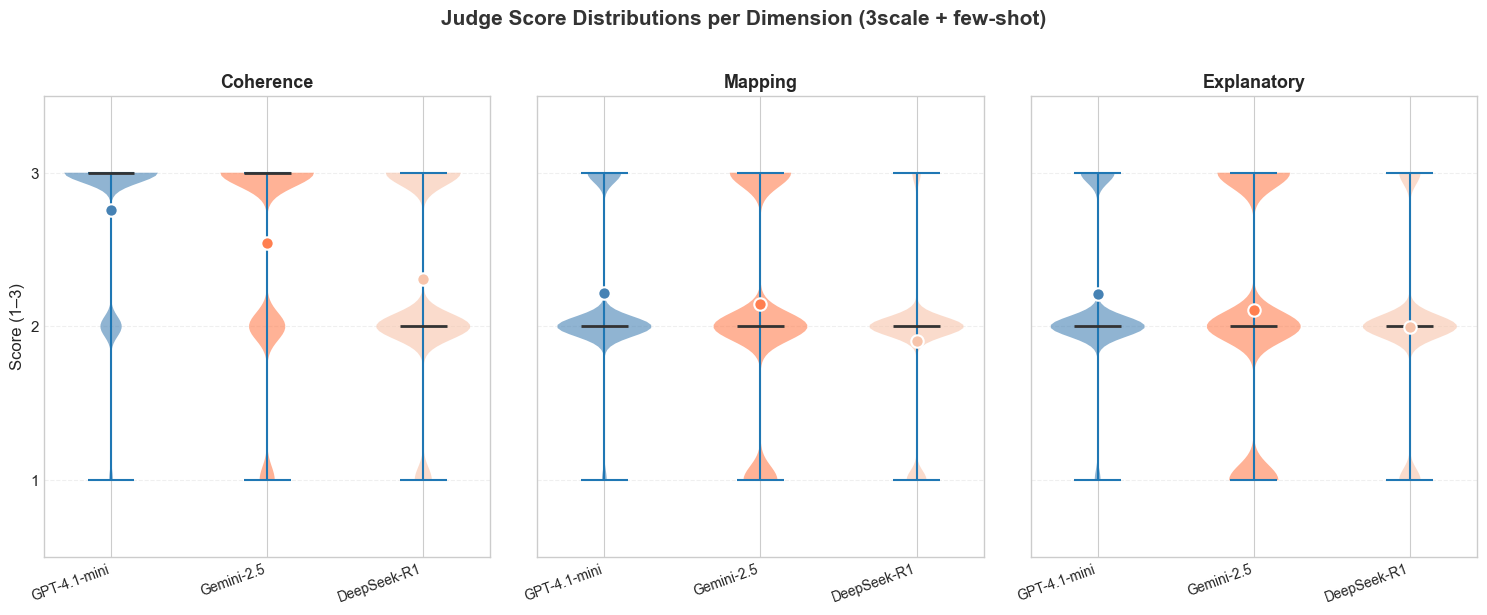

Saved: severity_violin_fewshot.png


In [189]:
# ============================================================
# CELL 3: Judge Severity — Violin Plots
# ============================================================

def plot_severity(df, mode_label, save_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

    dim_pairs = [('coh', 'Coherence'), ('map', 'Mapping'), ('exp', 'Explanatory')]

    for col_idx, (dim, dim_title) in enumerate(dim_pairs):
        ax = axes[col_idx]
        data_long = []
        for short in JUDGE_SHORTS:
            col = f'{short}_{dim}'
            vals = df[col].dropna().values
            data_long.append(pd.DataFrame({'score': vals, 'judge': JUDGE_FULL_NAMES[short]}))
        data_long = pd.concat(data_long, ignore_index=True)

        colors = [JUDGE_COLORS[s] for s in JUDGE_SHORTS]
        parts = ax.violinplot(
            [df[f'{s}_{dim}'].dropna().values for s in JUDGE_SHORTS],
            positions=[1, 2, 3], widths=0.6, showmedians=True
        )
        for i, (pc, c) in enumerate(zip(parts['bodies'], colors)):
            pc.set_facecolor(c)
            pc.set_alpha(0.6)
        parts['cmedians'].set_color('#333333')
        parts['cmedians'].set_linewidth(2)

        # Overlay mean dots
        for i, short in enumerate(JUDGE_SHORTS):
            mean_val = df[f'{short}_{dim}'].mean()
            ax.scatter(i + 1, mean_val, color=JUDGE_COLORS[short], s=80,
                       zorder=5, edgecolor='white', linewidth=1.5)

        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([JUDGE_FULL_NAMES[s] for s in JUDGE_SHORTS],
                           rotation=20, ha='right', fontsize=10)
        ax.set_title(dim_title, fontweight='bold', fontsize=13)
        ax.set_ylim(0.5, 3.5)
        ax.set_yticks([1, 2, 3])
        if col_idx == 0:
            ax.set_ylabel('Score (1–3)', fontsize=12)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

    plt.suptitle(f'Judge Score Distributions per Dimension ({mode_label})',
                 fontsize=15, fontweight='bold', color=COLORS['text'], y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_name}")

plot_severity(df_3scale,  '3scale',           'severity_violin_3scale.png')
plot_severity(df_fewshot, '3scale + few-shot', 'severity_violin_fewshot.png')

In [190]:
# ============================================================
# CELL 4: Judge Severity — Mean Score Summary Table
# ============================================================

def severity_table(df, mode_label):
    rows = []
    for short in JUDGE_SHORTS:
        row = {'Judge': JUDGE_FULL_NAMES[short]}
        for dim in DIMENSIONS:
            col = f'{short}_{dim}'
            vals = df[col].dropna()
            row[DIM_FULL[dim]] = f"{vals.mean():.3f} ± {vals.std():.3f}"
        row['Overall Avg'] = f"{df[f'{short}_avg'].mean():.3f}"
        rows.append(row)
    tbl = pd.DataFrame(rows).set_index('Judge')
    print(f"\n{'='*70}")
    print(f"Judge Mean Scores (mean ± std) — {mode_label}")
    print('='*70)
    print(tbl.to_string())
    return tbl

tbl_3s = severity_table(df_3scale,  '3scale')
tbl_fs = severity_table(df_fewshot, '3scale + few-shot')


Judge Mean Scores (mean ± std) — 3scale
                  Coherence        Mapping    Explanatory Overall Avg
Judge                                                                
GPT-4.1-mini  2.830 ± 0.429  2.305 ± 0.508  2.302 ± 0.519       2.479
Gemini-2.5    2.503 ± 0.788  2.388 ± 0.801  2.342 ± 0.829       2.411
DeepSeek-R1   2.347 ± 0.618  2.036 ± 0.470  2.089 ± 0.550       2.157

Judge Mean Scores (mean ± std) — 3scale + few-shot
                  Coherence        Mapping    Explanatory Overall Avg
Judge                                                                
GPT-4.1-mini  2.758 ± 0.496  2.219 ± 0.492  2.211 ± 0.503       2.396
Gemini-2.5    2.540 ± 0.676  2.144 ± 0.695  2.108 ± 0.744       2.264
DeepSeek-R1   2.310 ± 0.631  1.908 ± 0.473  2.000 ± 0.560       2.072


---
## Section 2: Overall Agreement Metrics

Using:
- **Krippendorff's α** (ordinal) — handles 3+ raters, ordinal scale
- **Fleiss' κ** — multi-rater generalization of Cohen's kappa
- **Pairwise Cohen's κ** (quadratic weighted) — all 3 pairs
- **% Exact agreement** — all 3 give identical integer score
- **% Near agreement** — all 3 within 1 point

In [191]:
# ============================================================
# CELL 5: Agreement Helper Functions
# ============================================================

# ---------- Krippendorff's alpha (built-in, no extra package needed) ----------

def _build_coincidences(data_idx: np.ndarray, n_cats: int, m: int) -> np.ndarray:
    """Build coincidences matrix from item × rater index array (0-indexed)."""
    C = np.zeros((n_cats, n_cats), dtype=float)
    weight = 1.0 / (m - 1)
    for u in range(m):
        for v in range(m):
            if u == v:
                continue
            # Count co-occurrences of each (ci, cj) pair across all items
            hist, _, _ = np.histogram2d(
                data_idx[:, u], data_idx[:, v],
                bins=n_cats, range=[[-0.5, n_cats - 0.5]] * 2
            )
            C += weight * hist
    return C


def krippendorff_alpha(r1, r2, r3, level='ordinal'):
    """
    Krippendorff's alpha for 3 raters, no external package required.
    level: 'interval' (default fallback) or 'ordinal'
    For a 3-point equal-spaced scale the two are nearly identical.
    """
    data = np.column_stack([r1, r2, r3]).astype(float)
    mask = ~np.any(np.isnan(data), axis=1)
    data = data[mask]
    n, m = data.shape
    if n < 2:
        return np.nan

    # Known value set {1, 2, 3} → 0-indexed {0, 1, 2}
    unique_vals = np.array([1.0, 2.0, 3.0])
    n_cats = len(unique_vals)
    all_flat = data.flatten()
    data_idx = (data - 1).astype(int)  # shape (n, 3), values in {0,1,2}

    # Distance matrix
    if level == 'interval':
        dist = (unique_vals[:, None] - unique_vals[None, :]) ** 2
    else:  # ordinal
        val_freq = np.array([(all_flat == v).sum() for v in unique_vals], dtype=float)
        dist = np.zeros((n_cats, n_cats))
        for i in range(n_cats):
            for j in range(n_cats):
                if i == j:
                    continue
                lo, hi = min(i, j), max(i, j)
                n_g = val_freq[lo: hi + 1].sum()
                dist[i, j] = (n_g - (val_freq[lo] + val_freq[hi]) / 2) ** 2

    C = _build_coincidences(data_idx, n_cats, m)
    n_c = C.sum(axis=1)       # marginal counts
    n_total = n_c.sum()

    D_o = np.sum(C * dist) / n_total
    D_e = np.sum(np.outer(n_c, n_c) * dist) / (n_total * (n_total - 1))

    if D_e == 0:
        return 1.0
    return float(1 - D_o / D_e)


# ---------- Fleiss' kappa ----------

def fleiss_kappa_manual(ratings: np.ndarray) -> float:
    """Fleiss' kappa — ratings shape (N, R), integer scores in {1,2,3}."""
    N, R = ratings.shape
    categories = [1, 2, 3]
    counts = np.zeros((N, len(categories)), dtype=float)
    for j, cat in enumerate(categories):
        counts[:, j] = (ratings == cat).sum(axis=1)
    p_j   = counts.sum(axis=0) / (N * R)
    P_i   = ((counts ** 2).sum(axis=1) - R) / (R * (R - 1))
    P_bar = P_i.mean()
    P_e   = (p_j ** 2).sum()
    if P_e == 1:
        return 1.0
    return float((P_bar - P_e) / (1 - P_e))


def compute_fleiss(r1, r2, r3):
    mask = ~(np.isnan(r1) | np.isnan(r2) | np.isnan(r3))
    ratings = np.column_stack([r1[mask], r2[mask], r3[mask]]).astype(int)
    if HAS_STATSMODELS:
        # aggregate_raters expects 0-indexed → shift {1,2,3} to {0,1,2}
        table, _ = aggregate_raters(ratings - 1, n_cat=3)
        return float(sm_fleiss(table))
    return fleiss_kappa_manual(ratings)


# ---------- Cohen's kappa (pairwise) ----------

def compute_pairwise_kappa(ra, rb):
    mask = ~(np.isnan(ra) | np.isnan(rb))
    return float(cohen_kappa_score(ra[mask].astype(int), rb[mask].astype(int),
                                   weights='quadratic'))


# ---------- Percent agreement ----------

def pct_exact(r1, r2, r3):
    mask = ~(np.isnan(r1) | np.isnan(r2) | np.isnan(r3))
    return float(((r1[mask] == r2[mask]) & (r2[mask] == r3[mask])).mean() * 100)


def pct_near(r1, r2, r3, tol=1):
    mask = ~(np.isnan(r1) | np.isnan(r2) | np.isnan(r3))
    r = np.column_stack([r1[mask], r2[mask], r3[mask]])
    return float(((r.max(axis=1) - r.min(axis=1)) <= tol).mean() * 100)


# ---------- Master report ----------

ALPHA_KEY = "Krippendorff's α"   # defined once to avoid backslash-in-f-string issues

def agreement_report(df, mode_label):
    """Compute all agreement metrics for all dimensions."""
    results = []
    for dim in DIMENSIONS + ['avg']:
        r = {s: df[f'{s}_{dim}'].values.astype(float) for s in JUDGE_SHORTS}
        r_gpt, r_gem, r_dsk = r['gpt'], r['gemini'], r['deepseek']

        row = {'Dimension': DIM_FULL.get(dim, 'Average (float)'), 'mode': mode_label}
        row[ALPHA_KEY]           = round(krippendorff_alpha(r_gpt, r_gem, r_dsk), 3)
        row["Fleiss' κ"]         = round(compute_fleiss(r_gpt, r_gem, r_dsk), 3) if dim != 'avg' else '—'
        row["GPT–Gemini κ"]      = round(compute_pairwise_kappa(r_gpt, r_gem), 3) if dim != 'avg' else '—'
        row["GPT–DeepSeek κ"]    = round(compute_pairwise_kappa(r_gpt, r_dsk), 3) if dim != 'avg' else '—'
        row["Gemini–DeepSeek κ"] = round(compute_pairwise_kappa(r_gem, r_dsk), 3) if dim != 'avg' else '—'
        if dim != 'avg':
            row['% Exact']  = round(pct_exact(r_gpt, r_gem, r_dsk), 1)
            row['% Near±1'] = round(pct_near(r_gpt,  r_gem, r_dsk, tol=1), 1)
        else:
            rr = {s: np.round(r[s]) for s in JUDGE_SHORTS}
            row['% Exact']  = round(pct_exact(rr['gpt'], rr['gemini'], rr['deepseek']), 1)
            row['% Near±1'] = '—'
        results.append(row)
    return pd.DataFrame(results).set_index('Dimension')

print("Agreement helper functions defined (Krippendorff's α computed natively).")

Agreement helper functions defined (Krippendorff's α computed natively).


In [192]:
# ============================================================
# CELL 6: Compute & Display Agreement Metrics
# ============================================================

rep_3s = agreement_report(df_3scale,  '3scale')
rep_fs = agreement_report(df_fewshot, '3scale_fewshot')

print("\n" + "="*80)
print("AGREEMENT METRICS — 3scale (no few-shot)")
print("="*80)
print(rep_3s.drop(columns=['mode']).to_string())

print("\n" + "="*80)
print("AGREEMENT METRICS — 3scale_fewshot")
print("="*80)
print(rep_fs.drop(columns=['mode']).to_string())


AGREEMENT METRICS — 3scale (no few-shot)
                 Krippendorff's α Fleiss' κ GPT–Gemini κ GPT–DeepSeek κ Gemini–DeepSeek κ  % Exact % Near±1
Dimension                                                                                                  
Coherence                   0.291     0.176        0.367          0.257             0.409     41.3     87.9
Mapping                     0.253     0.134        0.291          0.296             0.285     27.3     94.4
Explanatory                 0.325     0.185        0.302          0.364             0.383     29.3     94.0
Average (float)             0.249         —            —              —                 —     30.2        —

AGREEMENT METRICS — 3scale_fewshot
                 Krippendorff's α Fleiss' κ GPT–Gemini κ GPT–DeepSeek κ Gemini–DeepSeek κ  % Exact % Near±1
Dimension                                                                                                  
Coherence                   0.345     0.276         0.45  

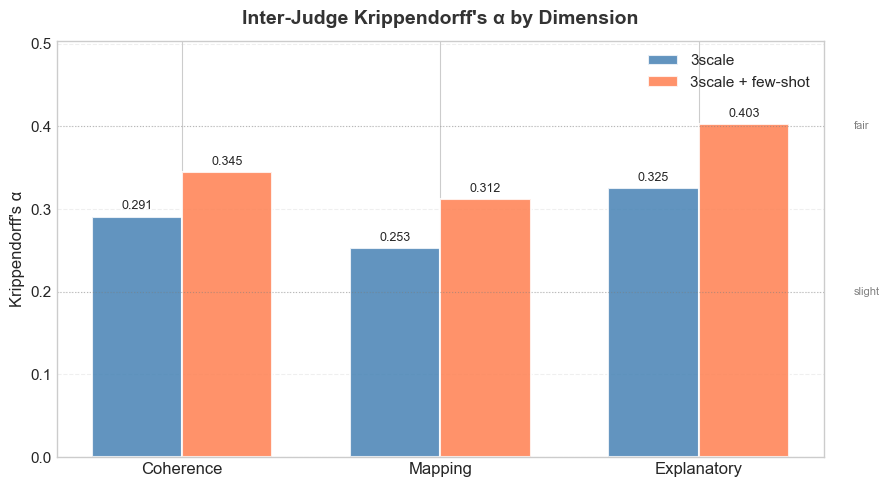

Saved: agreement_alpha.png


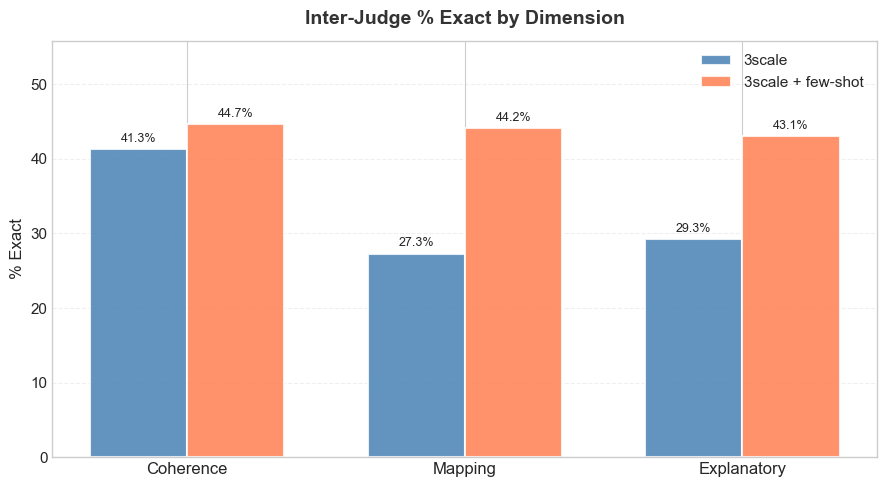

Saved: agreement_pct_exact.png


In [193]:
# ============================================================
# CELL 7: Agreement Metrics — Bar Chart (ACL style)
# ============================================================

def plot_agreement_bars(rep_3s, rep_fs, metric=ALPHA_KEY, save_name='agreement_alpha.png'):
    dims = ['Coherence', 'Mapping', 'Explanatory']

    def safe_float(val):
        try:
            v = float(val)
            return v if np.isfinite(v) else np.nan
        except (TypeError, ValueError):
            return np.nan

    vals_3s = [safe_float(rep_3s.loc[d, metric]) for d in dims]
    vals_fs = [safe_float(rep_fs.loc[d, metric]) for d in dims]

    all_vals = [v for v in vals_3s + vals_fs if not np.isnan(v)]
    if not all_vals:
        print(f"[!] All values for '{metric}' are NaN — skipping plot.")
        return
    y_max = max(all_vals) * 1.25 if max(all_vals) > 0 else 1.0

    x = np.arange(len(dims))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    b1 = ax.bar(x - width/2, vals_3s, width, label='3scale',
                color=COLORS['primary'],   alpha=0.85, edgecolor='white', linewidth=1.5)
    b2 = ax.bar(x + width/2, vals_fs, width, label='3scale + few-shot',
                color=COLORS['secondary'], alpha=0.85, edgecolor='white', linewidth=1.5)

    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            if np.isfinite(h):
                label_str = f'{h:.3f}' if h < 2 else f'{h:.1f}%'
                ax.text(bar.get_x() + bar.get_width()/2, h + y_max * 0.01,
                        label_str, ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(dims, fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Inter-Judge {metric} by Dimension', fontweight='bold',
                 fontsize=14, color=COLORS['text'], pad=12)
    ax.legend(fontsize=11, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, y_max)

    # Interpretation reference lines for kappa/alpha metrics
    if any(c in metric for c in ['α', 'κ']):
        for val, lbl in [(0.2, 'slight'), (0.4, 'fair'), (0.6, 'moderate'), (0.8, 'substantial')]:
            if val < y_max:
                ax.axhline(val, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
                ax.text(x[-1] + 0.6, val, lbl, color='gray', fontsize=8, va='center')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_name}")

plot_agreement_bars(rep_3s, rep_fs, metric=ALPHA_KEY,    save_name='agreement_alpha.png')
plot_agreement_bars(rep_3s, rep_fs, metric='% Exact',    save_name='agreement_pct_exact.png')

In [194]:
# ============================================================
# CELL 8: ICC (Intraclass Correlation Coefficient) — optional
# ============================================================

def compute_icc(df, mode_label, sample_size=5000):
    """Compute ICC using pingouin for each dimension."""
    if not HAS_PINGOUIN:
        print("[!] pingouin not available. Skipping ICC.")
        return

    print(f"\nICC results — {mode_label}")
    print('='*60)
    # Sample to keep runtime manageable
    df_sample = df.sample(min(sample_size, len(df)), random_state=42)

    for dim in DIMENSIONS:
        records = []
        for short in JUDGE_SHORTS:
            col = f'{short}_{dim}'
            tmp = df_sample[['record_id', col]].copy()
            tmp.columns = ['targets', 'ratings']
            tmp['raters'] = JUDGE_FULL_NAMES[short]
            records.append(tmp.dropna())
        long_df = pd.concat(records, ignore_index=True)
        icc = pg.intraclass_corr(data=long_df, targets='targets', raters='raters', ratings='ratings')
        # ICC(2,1) — two-way random, single measures
        icc21 = icc[icc['Type'] == 'ICC2'].iloc[0]
        print(f"  {DIM_FULL[dim]:12s}: ICC2 = {icc21['ICC']:.3f}  "
              f"95%CI [{icc21['CI95%'][0]:.3f}, {icc21['CI95%'][1]:.3f}]")

compute_icc(df_3scale,  '3scale')
compute_icc(df_fewshot, '3scale + few-shot')

[!] pingouin not available. Skipping ICC.
[!] pingouin not available. Skipping ICC.


---
## Section 3: Pairwise Confusion Matrices

For each pair of judges, a 3×3 heatmap shows how often they assign the same/different scores.

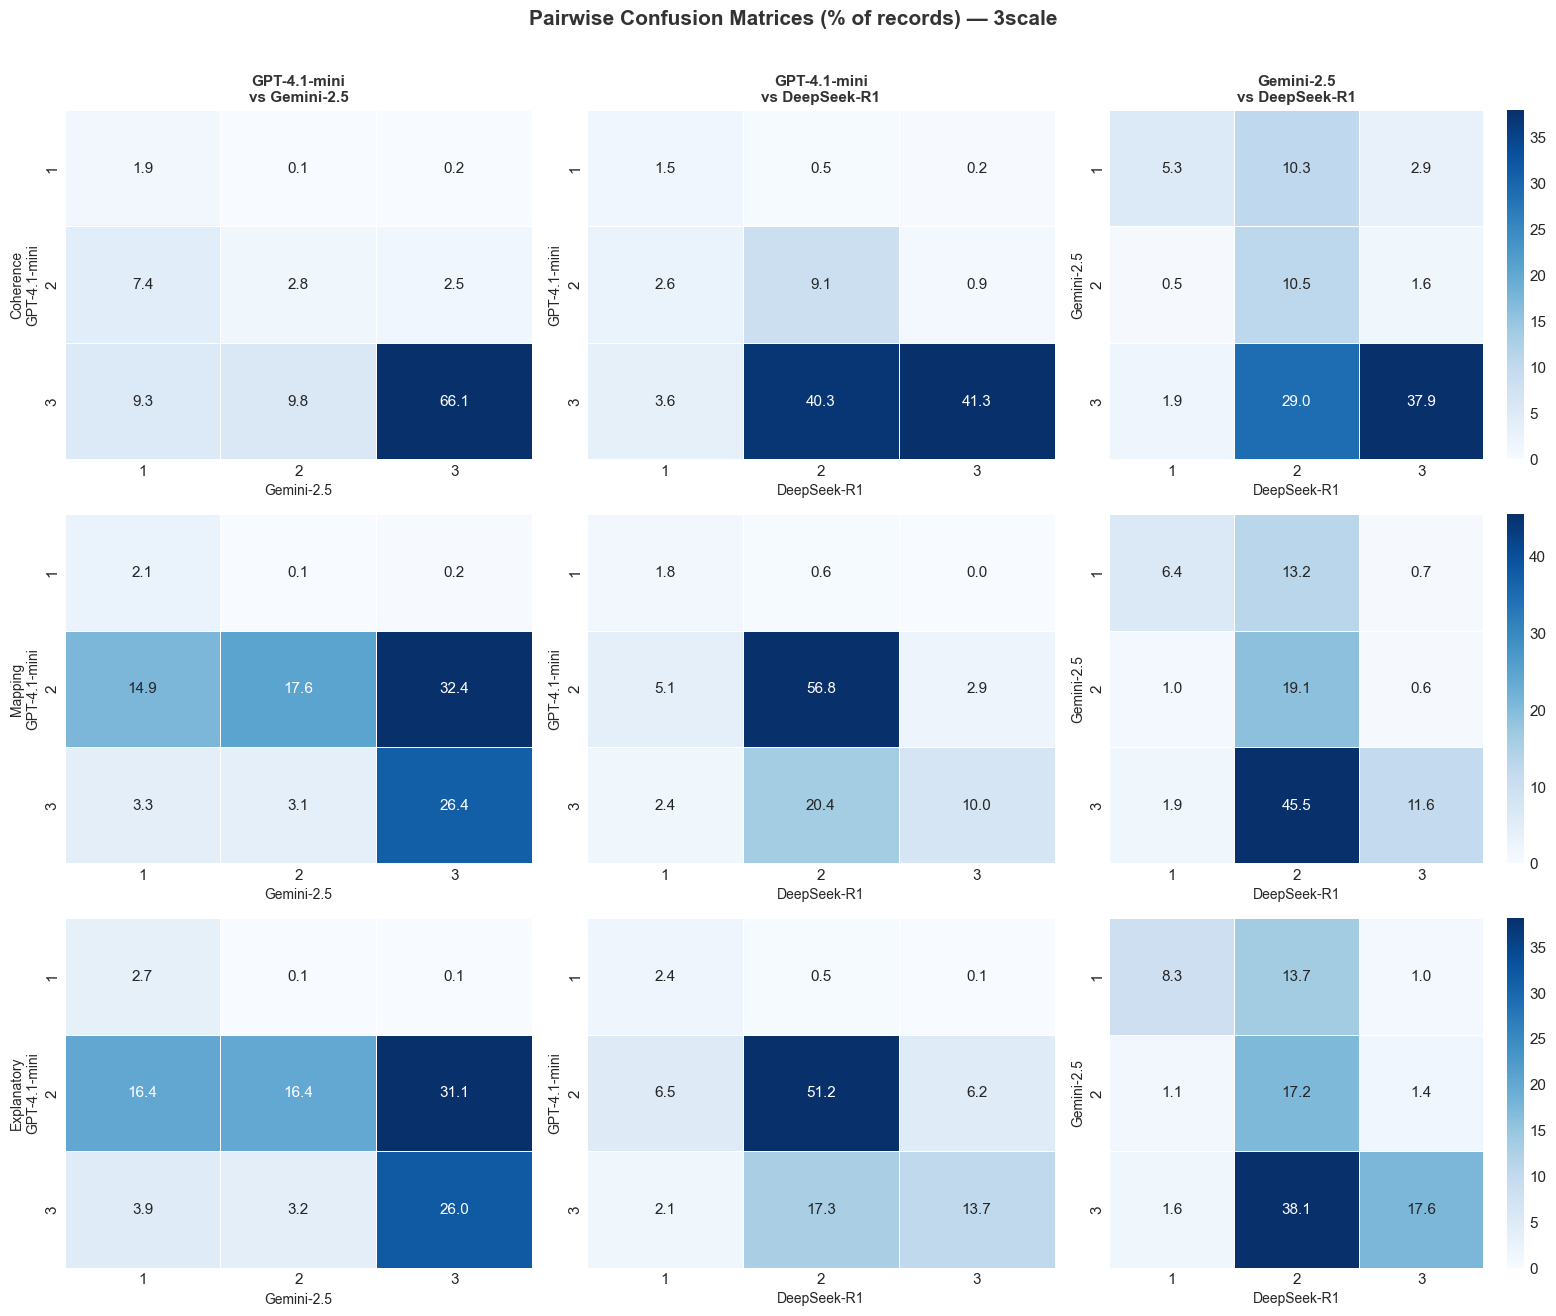

Saved: confusion_matrices_3scale.png


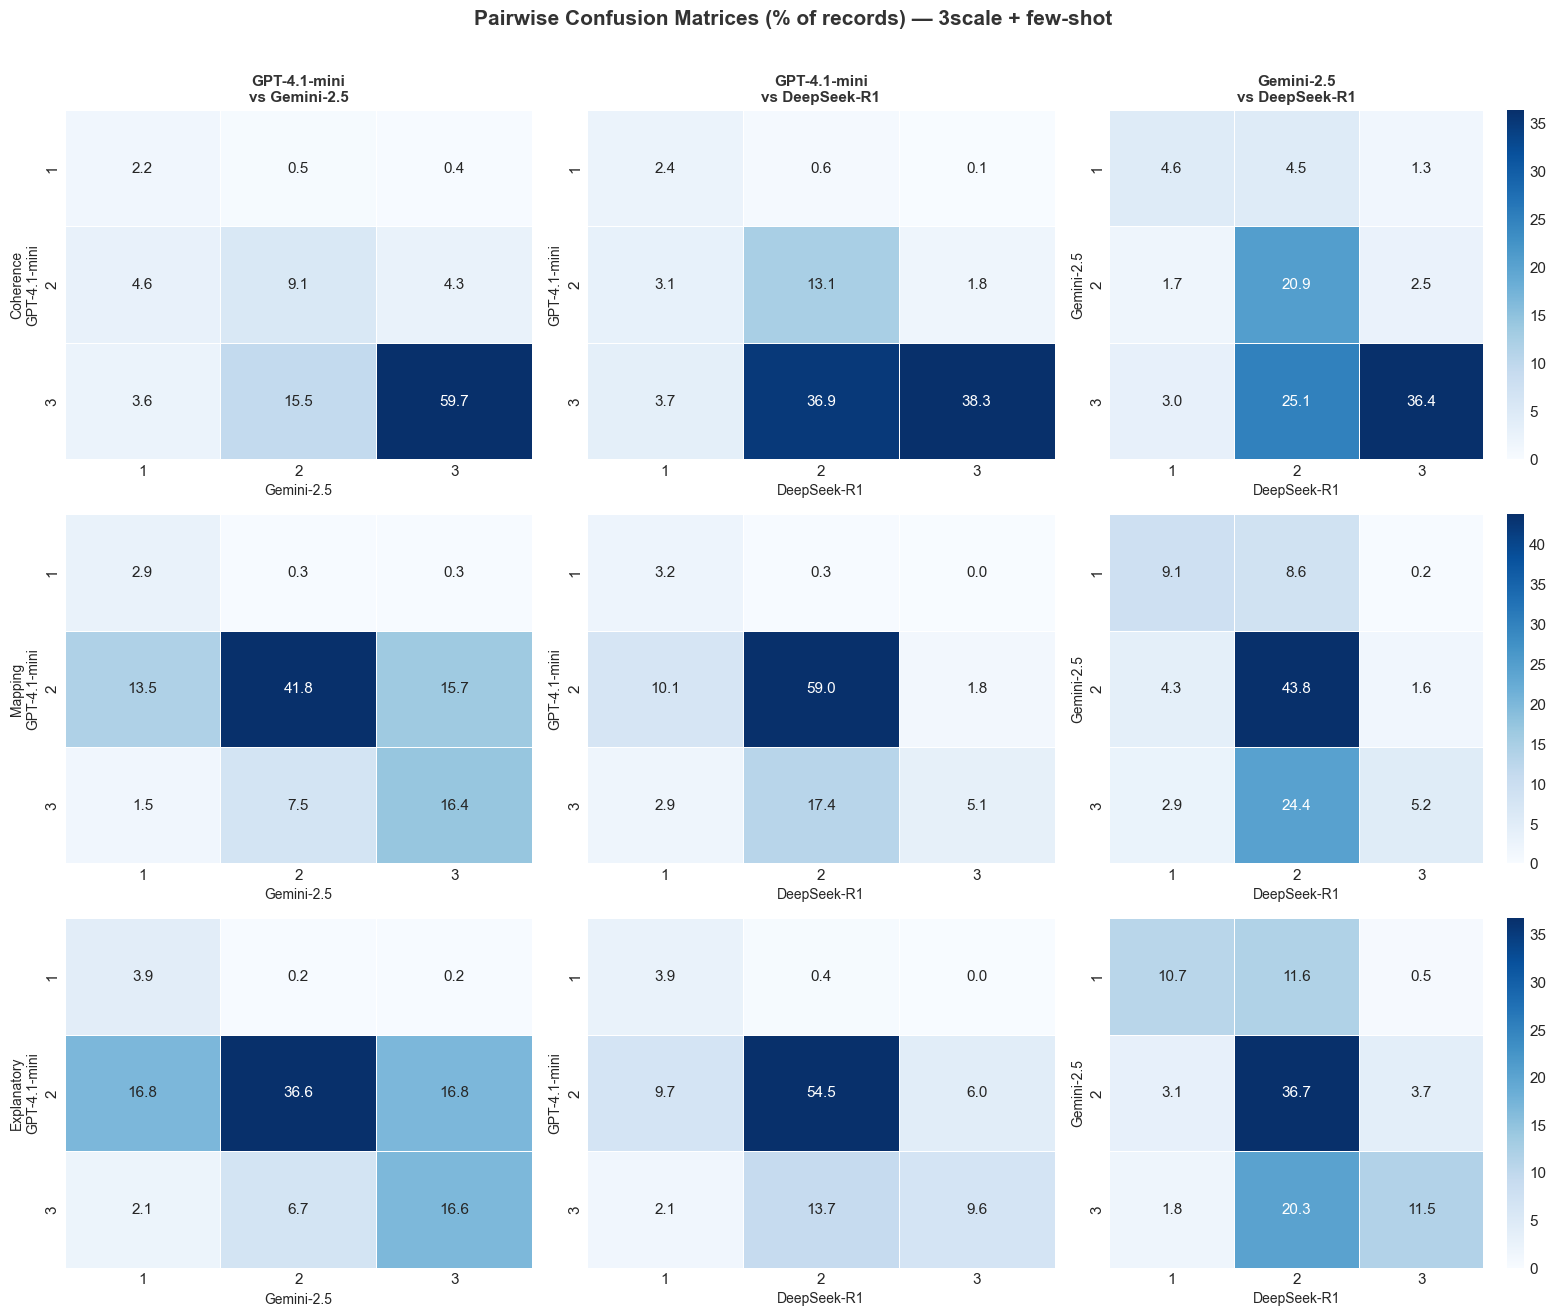

Saved: confusion_matrices_fewshot.png


In [195]:
# ============================================================
# CELL 9: Pairwise Confusion Matrices (normalized %)
# ============================================================

def plot_confusion_matrices(df, mode_label, save_name):
    pairs = [
        ('gpt', 'gemini'),
        ('gpt', 'deepseek'),
        ('gemini', 'deepseek'),
    ]
    dims = DIMENSIONS  # ['coh', 'map', 'exp']

    fig, axes = plt.subplots(len(dims), len(pairs), figsize=(16, 13))

    for row_idx, dim in enumerate(dims):
        for col_idx, (j1, j2) in enumerate(pairs):
            ax = axes[row_idx, col_idx]
            c1 = df[f'{j1}_{dim}'].dropna()
            c2 = df[f'{j2}_{dim}'].dropna()
            common_idx = c1.index.intersection(c2.index)
            v1 = c1.loc[common_idx].astype(int)
            v2 = c2.loc[common_idx].astype(int)

            # Build 3x3 confusion matrix
            cm = np.zeros((3, 3), dtype=int)
            for a, b in zip(v1, v2):
                cm[a-1, b-1] += 1
            cm_pct = cm / cm.sum() * 100

            sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                        ax=ax, vmin=0, vmax=cm_pct.max(),
                        linewidths=0.5, linecolor='white',
                        xticklabels=[1, 2, 3], yticklabels=[1, 2, 3],
                        cbar=(col_idx == len(pairs)-1))
            ax.set_xlabel(JUDGE_FULL_NAMES[j2], fontsize=10)
            ax.set_ylabel(JUDGE_FULL_NAMES[j1], fontsize=10)

            # Title only on top row
            if row_idx == 0:
                ax.set_title(f'{JUDGE_FULL_NAMES[j1]}\nvs {JUDGE_FULL_NAMES[j2]}',
                             fontsize=11, fontweight='bold', color=COLORS['text'])
            # Dim label only on left column
            if col_idx == 0:
                ax.set_ylabel(f'{DIM_FULL[dim]}\n{JUDGE_FULL_NAMES[j1]}',
                               fontsize=10, labelpad=4)

    plt.suptitle(f'Pairwise Confusion Matrices (% of records) — {mode_label}',
                 fontsize=15, fontweight='bold', color=COLORS['text'], y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_name}")

plot_confusion_matrices(df_3scale,  '3scale',           'confusion_matrices_3scale.png')
plot_confusion_matrices(df_fewshot, '3scale + few-shot', 'confusion_matrices_fewshot.png')

---
## Section 4: Agreement Category Analysis

For each record, we check whether all 3, exactly 2 (and which pair), or none of the judges assign the same integer score on each dimension.

- **All agree**: all 3 give identical score
- **GPT ∩ Gemini**: only GPT and Gemini match (DeepSeek differs)
- **GPT ∩ DeepSeek**: only GPT and DeepSeek match
- **Gemini ∩ DeepSeek**: only Gemini and DeepSeek match
- **None agree**: all 3 differ

In [196]:

# ============================================================
# CELL 10: Categorize Agreement per Record
# ============================================================

def categorize_agreement_dim(df, dim):
    """
    Per-dimension agreement category (used by stacked bar chart).
    Categories: 'all_agree', 'gpt_gemini', 'gpt_deepseek',
                'gemini_deepseek', 'none_agree', 'missing'
    """
    g  = df[f'gpt_{dim}'].values.astype(float)
    ge = df[f'gemini_{dim}'].values.astype(float)
    d  = df[f'deepseek_{dim}'].values.astype(float)

    cats = []
    for gi, gei, di in zip(g, ge, d):
        if np.isnan(gi) or np.isnan(gei) or np.isnan(di):
            cats.append('missing')
        elif gi == gei == di:
            cats.append('all_agree')
        elif gi == gei:
            cats.append('gpt_gemini')
        elif gi == di:
            cats.append('gpt_deepseek')
        elif gei == di:
            cats.append('gemini_deepseek')
        else:
            cats.append('none_agree')
    return pd.Categorical(cats,
        categories=['all_agree', 'gpt_gemini', 'gpt_deepseek',
                    'gemini_deepseek', 'none_agree', 'missing'],
        ordered=True)


def categorize_agreement_overall(df):
    """
    Overall agreement across ALL 3 dimensions (coh + map + exp).
    A pair 'agrees' only if they match on every dimension.
    Vectorized for speed.
    """
    gpt_gem = np.ones(len(df), dtype=bool)
    gpt_dsk = np.ones(len(df), dtype=bool)
    gem_dsk = np.ones(len(df), dtype=bool)
    any_nan = np.zeros(len(df), dtype=bool)

    for d in ['coh', 'map', 'exp']:
        g  = df[f'gpt_{d}'].values.astype(float)
        ge = df[f'gemini_{d}'].values.astype(float)
        dk = df[f'deepseek_{d}'].values.astype(float)
        any_nan |= np.isnan(g) | np.isnan(ge) | np.isnan(dk)
        gpt_gem &= (g == ge)
        gpt_dsk &= (g == dk)
        gem_dsk &= (ge == dk)

    cats = np.where(any_nan,           'missing',
           np.where(gpt_gem & gpt_dsk, 'all_agree',
           np.where(gpt_gem,           'gpt_gemini',
           np.where(gpt_dsk,           'gpt_deepseek',
           np.where(gem_dsk,           'gemini_deepseek',
                                       'none_agree')))))
    return pd.Categorical(cats,
        categories=['all_agree', 'gpt_gemini', 'gpt_deepseek',
                    'gemini_deepseek', 'none_agree', 'missing'],
        ordered=True)


def add_agreement_columns(df):
    df = df.copy()
    # Per-dimension (used by stacked bar chart)
    for dim in DIMENSIONS:
        df[f'agree_{dim}'] = categorize_agreement_dim(df, dim)
    # Overall across all 3 dimensions (used for CSV bucketing)
    df['agree_overall'] = categorize_agreement_overall(df)
    # Strict boolean: all 3 judges agree on all 3 dimensions
    df['agree_all_dims'] = (df['agree_overall'] == 'all_agree')
    return df


df_3scale  = add_agreement_columns(df_3scale)
df_fewshot = add_agreement_columns(df_fewshot)

print("Agreement columns added.")
print("\n--- 3scale: Overall agreement distribution (all 3 dimensions) ---")
print(df_3scale['agree_overall'].value_counts())
print("\n--- 3scale_fewshot: Overall agreement distribution (all 3 dimensions) ---")
print(df_fewshot['agree_overall'].value_counts())


Agreement columns added.

--- 3scale: Overall agreement distribution (all 3 dimensions) ---
agree_overall
none_agree         8213
gpt_gemini         5558
gpt_deepseek       4580
gemini_deepseek    3438
all_agree          3369
missing               0
Name: count, dtype: int64

--- 3scale_fewshot: Overall agreement distribution (all 3 dimensions) ---
agree_overall
gpt_gemini         6454
none_agree         6246
gemini_deepseek    4369
all_agree          4118
gpt_deepseek       3972
missing               0
Name: count, dtype: int64


In [197]:

# ============================================================
# CELL 11: Agreement Category Summary Table
# ============================================================

CATEGORY_LABELS = {
    'all_agree':        'All 3 agree',
    'gpt_gemini':       'GPT ∩ Gemini only',
    'gpt_deepseek':     'GPT ∩ DeepSeek only',
    'gemini_deepseek':  'Gemini ∩ DeepSeek only',
    'none_agree':       'None agree',
}

def agreement_summary_table(df, mode_label):
    N = len(df)

    # ── Per-dimension breakdown ──────────────────────────────
    rows = []
    for dim in DIMENSIONS:
        col = f'agree_{dim}'
        vc = df[col].value_counts()
        for cat, label in CATEGORY_LABELS.items():
            rows.append({
                'Dimension':  DIM_FULL[dim],
                'Category':   label,
                'Count':      vc.get(cat, 0),
                '% Records':  round(vc.get(cat, 0) / N * 100, 1),
            })
    tbl = pd.DataFrame(rows).pivot(index='Category', columns='Dimension',
                                   values=['Count', '% Records'])
    print(f"\n{'='*80}")
    print(f"AGREEMENT CATEGORY TABLE — {mode_label}  (N={N:,})")
    print('='*80)
    print("Per-dimension breakdown (% of records):")
    print(tbl['% Records'].to_string())

    # ── Overall (all 3 dimensions) ───────────────────────────
    print(f"\nOverall agreement (all 3 dimensions simultaneously):")
    vc_overall = df['agree_overall'].value_counts()
    for cat, label in CATEGORY_LABELS.items():
        cnt = vc_overall.get(cat, 0)
        print(f"  {label:25s}: {cnt:6,}  ({cnt/N*100:.1f}%)")
    missing = vc_overall.get('missing', 0)
    if missing:
        print(f"  {'missing':25s}: {missing:6,}  ({missing/N*100:.1f}%)")

    return tbl

tbl_3s_cats  = agreement_summary_table(df_3scale,  '3scale')
tbl_fs_cats  = agreement_summary_table(df_fewshot, '3scale + few-shot')



AGREEMENT CATEGORY TABLE — 3scale  (N=25,158)
Per-dimension breakdown (% of records):
Dimension               Coherence  Explanatory  Mapping
Category                                               
All 3 agree                  41.3         29.3     27.3
GPT ∩ DeepSeek only          10.6         38.0     41.3
GPT ∩ Gemini only            29.5         15.8     18.8
Gemini ∩ DeepSeek only       12.5         13.7      9.9
None agree                    6.1          3.2      2.7

Overall agreement (all 3 dimensions simultaneously):
  All 3 agree              :  3,369  (13.4%)
  GPT ∩ Gemini only        :  5,558  (22.1%)
  GPT ∩ DeepSeek only      :  4,580  (18.2%)
  Gemini ∩ DeepSeek only   :  3,438  (13.7%)
  None agree               :  8,213  (32.6%)

AGREEMENT CATEGORY TABLE — 3scale + few-shot  (N=25,159)
Per-dimension breakdown (% of records):
Dimension               Coherence  Explanatory  Mapping
Category                                               
All 3 agree                  44.

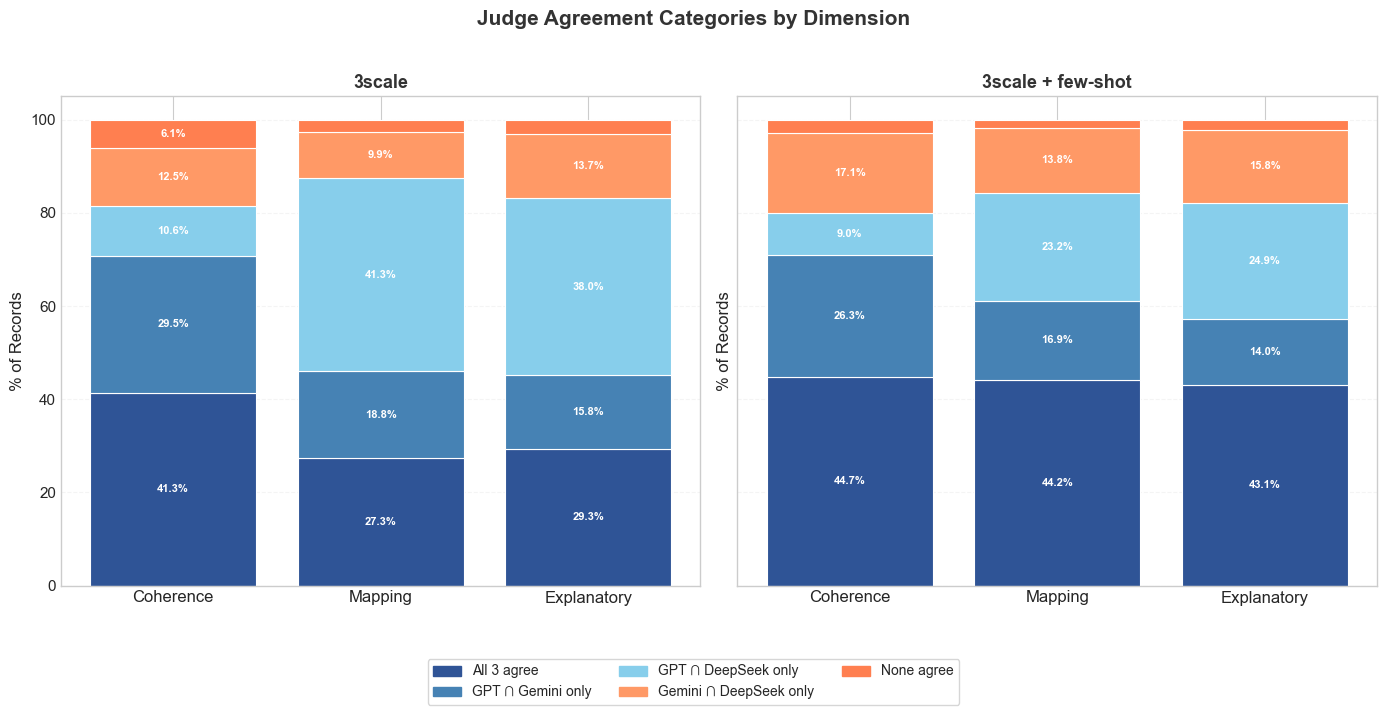

Saved: agreement_categories_stacked.png


In [198]:
# ============================================================
# CELL 12: Agreement Category — Stacked Bar Chart
# ============================================================

CAT_COLORS = [
    '#2F5496',   # all agree — dark blue
    '#4682B4',   # gpt∩gemini — steel blue
    '#87CEEB',   # gpt∩deepseek — sky blue
    '#FF9966',   # gemini∩deepseek — coral
    '#FF7F50',   # none agree — orange
]

def plot_agreement_stacked(df_list, mode_labels, save_name):
    n_modes = len(df_list)
    fig, axes = plt.subplots(1, n_modes, figsize=(7 * n_modes, 6), sharey=True)
    if n_modes == 1:
        axes = [axes]

    cats_order = ['all_agree', 'gpt_gemini', 'gpt_deepseek', 'gemini_deepseek', 'none_agree']

    for ax, df, mode_label in zip(axes, df_list, mode_labels):
        N = len(df)
        x = np.arange(len(DIMENSIONS))
        bottoms = np.zeros(len(DIMENSIONS))

        for ci, cat in enumerate(cats_order):
            vals = []
            for dim in DIMENSIONS:
                col = f'agree_{dim}'
                pct = (df[col] == cat).sum() / N * 100
                vals.append(pct)
            vals = np.array(vals)
            bars = ax.bar(x, vals, bottom=bottoms, color=CAT_COLORS[ci],
                          label=CATEGORY_LABELS[cat], edgecolor='white', linewidth=0.8)
            # Add % labels if large enough
            for xi, (v, b) in enumerate(zip(vals, bottoms)):
                if v > 4:
                    ax.text(xi, b + v/2, f'{v:.1f}%', ha='center', va='center',
                            fontsize=8, color='white', fontweight='bold')
            bottoms += vals

        ax.set_xticks(x)
        ax.set_xticklabels([DIM_FULL[d] for d in DIMENSIONS], fontsize=12)
        ax.set_title(mode_label, fontsize=13, fontweight='bold', color=COLORS['text'])
        ax.set_ylabel('% of Records', fontsize=12)
        ax.set_ylim(0, 105)
        ax.grid(axis='y', alpha=0.2, linestyle='--')

    # Shared legend
    handles = [mpatches.Patch(color=CAT_COLORS[i], label=CATEGORY_LABELS[c])
               for i, c in enumerate(cats_order)]
    fig.legend(handles=handles, loc='upper center',
               bbox_to_anchor=(0.5, -0.05), ncol=3,
               fontsize=10, frameon=True, fancybox=True)

    plt.suptitle('Judge Agreement Categories by Dimension',
                 fontsize=15, fontweight='bold', color=COLORS['text'], y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_name}")

plot_agreement_stacked(
    [df_3scale, df_fewshot],
    ['3scale', '3scale + few-shot'],
    'agreement_categories_stacked.png'
)

In [199]:

# ============================================================
# CELL 13: Agreement Category Examples → CSV files
# Categorized by overall agreement across ALL 3 dimensions
# ============================================================

EXAMPLES_DIR = OUTPUT_DIR / 'agreement_examples'
EXAMPLES_DIR.mkdir(parents=True, exist_ok=True)

SCORE_COLS = [
    'gpt_coh',  'gpt_map',  'gpt_exp',  'gpt_avg',
    'gemini_coh','gemini_map','gemini_exp','gemini_avg',
    'deepseek_coh','deepseek_map','deepseek_exp','deepseek_avg',
]
# Columns exported to CSV:
#   target         — the concept being analogised
#   target_domain  — scientific domain from SCAR (e.g. Biology, Physics)
#   chosen_analogy — the source analogy chosen
#   model          — which generator model produced this record
#   original_mode  — retrieval method: targetonly or withsub
#   analogy_type   — selection strategy: baseline / embedding / rerank
#   source_dataset — file/split it came from (stage2_targetonly, stage2_withsub, stage1)
#   agree_overall  — agreement across ALL 3 dimensions simultaneously
#   agree_coh/map/exp — per-dimension breakdown (shows where disagreement occurs)
META_EXPORT = ['target', 'target_domain', 'chosen_analogy', 'model',
               'original_mode', 'analogy_type', 'source_dataset',
               'agree_overall', 'agree_coh', 'agree_map', 'agree_exp']

def save_agreement_csvs(df, mode_label, file_suffix):
    """
    For each overall agreement category, save a sorted CSV.
    Sorted by consensus_avg descending (highest quality first).
    Bucketed by agree_overall (all 3 dimensions, not just coherence).
    """
    df = df.copy()
    df['consensus_avg'] = df[['gpt_avg', 'gemini_avg', 'deepseek_avg']].mean(axis=1)
    export_cols = META_EXPORT + SCORE_COLS + ['consensus_avg']

    print(f"\n{'='*70}")
    print(f"Agreement category CSVs — {mode_label}  (overall: all 3 dimensions)")
    print(f"Saved to: {EXAMPLES_DIR}")
    print('='*70)

    for cat, label in CATEGORY_LABELS.items():
        subset = df[df['agree_overall'] == cat].copy()
        subset = subset.sort_values('consensus_avg', ascending=False)
        cols = [c for c in export_cols if c in subset.columns]
        subset[cols].to_csv(EXAMPLES_DIR / f'{file_suffix}_{cat}.csv', index=False)
        print(f"  [{label:25s}]  {len(subset):6,} records  →  {file_suffix}_{cat}.csv")

    print()

save_agreement_csvs(df_3scale,  '3scale',        '3scale')
save_agreement_csvs(df_fewshot, '3scale_fewshot', 'fewshot')

# ── Quick inline preview (top 2 per category, 3scale) ───────────────────────
print("\nQuick preview — 3scale, Overall agreement (all 3 dimensions)\n")
df_preview = df_3scale.copy()
df_preview['consensus_avg'] = df_preview[['gpt_avg', 'gemini_avg', 'deepseek_avg']].mean(axis=1)

for cat, label in CATEGORY_LABELS.items():
    subset = df_preview[df_preview['agree_overall'] == cat].sort_values('consensus_avg', ascending=False)
    if len(subset) == 0:
        continue
    print(f"{'─'*70}")
    print(f"[{label}]  (n={len(subset):,})")
    for _, row in subset.head(2).iterrows():
        domain = row.get('target_domain', '—')
        mode   = row.get('original_mode', '—')
        scores_str = (f"GPT={row['gpt_avg']:.2f}  "
                      f"Gem={row['gemini_avg']:.2f}  "
                      f"DSk={row['deepseek_avg']:.2f}  "
                      f"consensus={row['consensus_avg']:.2f}")
        dim_agree = (f"coh:{row['agree_coh']}  "
                     f"map:{row['agree_map']}  "
                     f"exp:{row['agree_exp']}")
        print(f"  Target        : {row['target']}  [{domain}]")
        print(f"  Analogy       : {row['chosen_analogy']}")
        print(f"  Model / Mode  : {MODEL_ABBREV.get(row['model'], row['model'])} / {mode}")
        print(f"  Source file   : {row['source_dataset']}")
        print(f"  Strategy      : {row['analogy_type']}")
        print(f"  Avg scores    : {scores_str}")
        print(f"  Dim agreement : {dim_agree}")
        print()



Agreement category CSVs — 3scale  (overall: all 3 dimensions)
Saved to: ..\results\judge_analysis\agreement_examples
  [All 3 agree              ]   3,369 records  →  3scale_all_agree.csv
  [GPT ∩ Gemini only        ]   5,558 records  →  3scale_gpt_gemini.csv
  [GPT ∩ DeepSeek only      ]   4,580 records  →  3scale_gpt_deepseek.csv
  [Gemini ∩ DeepSeek only   ]   3,438 records  →  3scale_gemini_deepseek.csv
  [None agree               ]   8,213 records  →  3scale_none_agree.csv


Agreement category CSVs — 3scale_fewshot  (overall: all 3 dimensions)
Saved to: ..\results\judge_analysis\agreement_examples
  [All 3 agree              ]   4,118 records  →  fewshot_all_agree.csv
  [GPT ∩ Gemini only        ]   6,454 records  →  fewshot_gpt_gemini.csv
  [GPT ∩ DeepSeek only      ]   3,972 records  →  fewshot_gpt_deepseek.csv
  [Gemini ∩ DeepSeek only   ]   4,369 records  →  fewshot_gemini_deepseek.csv
  [None agree               ]   6,246 records  →  fewshot_none_agree.csv


Quick preview — 

---
## Section 5: Model Ranking Comparison

> **Research question:** Do the three judges agree on which *generator* models produce the best analogies? Is the best→worst ordering consistent?

We focus on `analogy_type == 'rerank'` (the most refined selection strategy) for a clean comparison.

In [200]:

# ============================================================
# CELL 14: Compute Model Rankings per Judge
# Includes 12 LLM generators (analogy_type='rerank') +
# retrieval-based baseline from stage1 (analogy_type='pipeline_results')
# ============================================================

def compute_model_rankings(df, label=''):
    """
    For each generator model (including retrieval-based stage1 models),
    compute mean average_score per judge.
    - Stage2 LLM records: filtered to analogy_type='rerank'
    - Stage1 retrieval records: filtered to analogy_type='pipeline_results'
    Returns a DataFrame with per-judge mean scores and ranks (1 = best).
    """
    stage2_sub = df[(df['source_dataset'] != 'stage1') & (df['analogy_type'] == 'rerank')]
    stage1_sub = df[(df['source_dataset'] == 'stage1') & (df['analogy_type'] == 'pipeline_results')]
    sub = pd.concat([stage2_sub, stage1_sub], ignore_index=True)

    if len(sub) == 0:
        print(f"  [!] No records for {label}. Skipping.")
        return pd.DataFrame()

    rows = []
    for model in sorted(sub['model'].unique()):
        mdf = sub[sub['model'] == model]
        row = {'model': model, 'model_label': MODEL_ABBREV.get(model, model)}
        for short in JUDGE_SHORTS:
            row[f'{short}_mean'] = mdf[f'{short}_avg'].mean()
        rows.append(row)
    rank_df = pd.DataFrame(rows)

    for short in JUDGE_SHORTS:
        rank_df[f'{short}_rank'] = rank_df[f'{short}_mean'].rank(ascending=False).astype(int)

    n2 = len(stage2_sub)
    n1 = len(stage1_sub)
    print(f"\nModel rankings — {label}  (stage2 rerank n={n2:,}, stage1 pipeline n={n1:,})")
    print('='*70)
    print(rank_df[['model_label'] + [f'{s}_rank' for s in JUDGE_SHORTS]
                  + [f'{s}_mean' for s in JUDGE_SHORTS]].to_string(index=False))

    pairs = [('gpt', 'gemini'), ('gpt', 'deepseek'), ('gemini', 'deepseek')]
    print("\nSpearman rank correlations:")
    for j1, j2 in pairs:
        rho, p = stats.spearmanr(rank_df[f'{j1}_rank'].values,
                                  rank_df[f'{j2}_rank'].values)
        print(f"  {JUDGE_FULL_NAMES[j1]:12s} vs {JUDGE_FULL_NAMES[j2]:12s}: "
              f"rho = {rho:.3f}  (p = {p:.4f})")
    return rank_df

ranks_3s = compute_model_rankings(df_3scale,  label='3scale')
ranks_fs = compute_model_rankings(df_fewshot, label='3scale_fewshot')



Model rankings — 3scale  (stage2 rerank n=7,584, stage1 pipeline n=400)
    model_label  gpt_rank  gemini_rank  deepseek_rank  gpt_mean  gemini_mean  deepseek_mean
    DeepSeek-R1        12            1             12  2.576826     2.699375       2.245584
     Gemini-2.5         3            4              5  2.661980     2.682240       2.290754
   GPT-4.1-mini         8            8              3  2.615689     2.657304       2.302647
   GPT-4.1-nano         5           11             10  2.625634     2.543610       2.270501
   GPT-OSS-120B         9            2              7  2.614682     2.697111       2.286086
    GPT-OSS-20B        11            7             11  2.584095     2.665107       2.252852
         Grok-4        10            5              9  2.607459     2.680163       2.274658
     Llama-405B         2            6              2  2.664057     2.678606       2.313599
      Llama-70B         4            9              6  2.642211     2.648464       2.289646
       

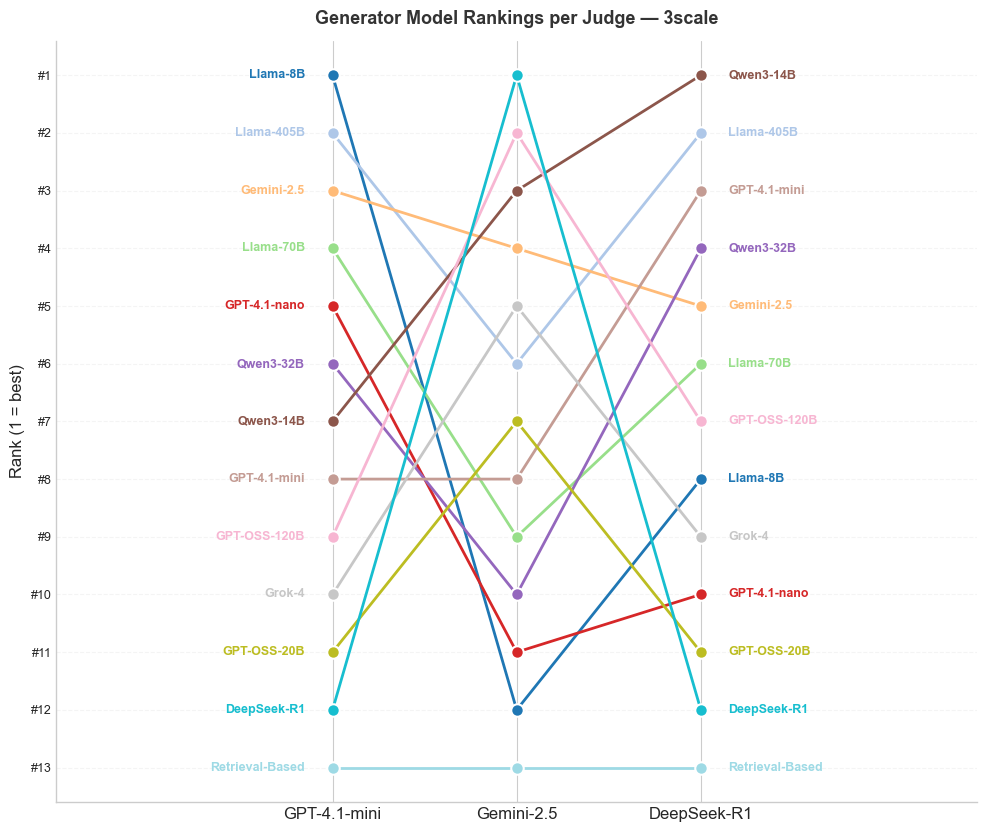

Saved: model_rankings_bump_3scale.png


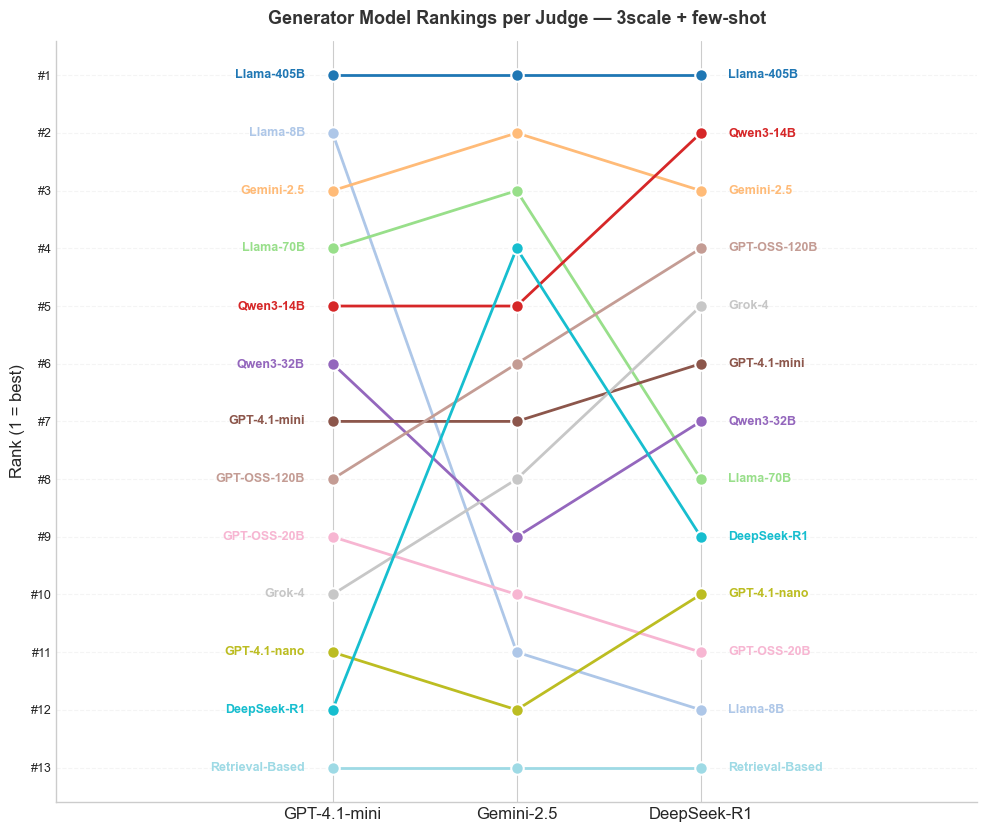

Saved: model_rankings_bump_fewshot.png


In [201]:

# ============================================================
# CELL 15: Bump Charts — Model Rankings per Judge
# One chart per judge mode (3scale / 3scale_fewshot)
# ============================================================

def plot_bump_chart(rank_df, title, save_name):
    if rank_df is None or len(rank_df) == 0:
        print(f"[!] No data for {title}. Skipping.")
        return
    n_models = len(rank_df)
    judge_labels = [JUDGE_FULL_NAMES[s] for s in JUDGE_SHORTS]
    x_pos = [0, 1, 2]
    palette = plt.cm.tab20(np.linspace(0, 1, n_models))

    fig, ax = plt.subplots(figsize=(10, max(6, n_models * 0.65)))
    for i, (_, row) in enumerate(rank_df.sort_values('gpt_rank').iterrows()):
        ranks_vals = [row[f'{s}_rank'] for s in JUDGE_SHORTS]
        color = palette[i]
        ax.plot(x_pos, ranks_vals, '-o', color=color, linewidth=2,
                markersize=9, markeredgecolor='white', markeredgewidth=1.5)
        ax.text(-0.15, ranks_vals[0],  row['model_label'], ha='right', va='center',
                fontsize=9, color=color, fontweight='bold')
        ax.text( 2.15, ranks_vals[-1], row['model_label'], ha='left',  va='center',
                fontsize=9, color=color, fontweight='bold')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(judge_labels, fontsize=12)
    ax.set_yticks(range(1, n_models + 1))
    ax.set_yticklabels([f'#{r}' for r in range(1, n_models + 1)], fontsize=9)
    ax.set_ylabel('Rank (1 = best)', fontsize=12)
    ax.invert_yaxis()
    ax.set_xlim(-1.5, 3.5)
    ax.set_title(title, fontsize=13, fontweight='bold', color=COLORS['text'], pad=12)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_name}")

plot_bump_chart(ranks_3s,
                'Generator Model Rankings per Judge — 3scale',
                'model_rankings_bump_3scale.png')
plot_bump_chart(ranks_fs,
                'Generator Model Rankings per Judge — 3scale + few-shot',
                'model_rankings_bump_fewshot.png')


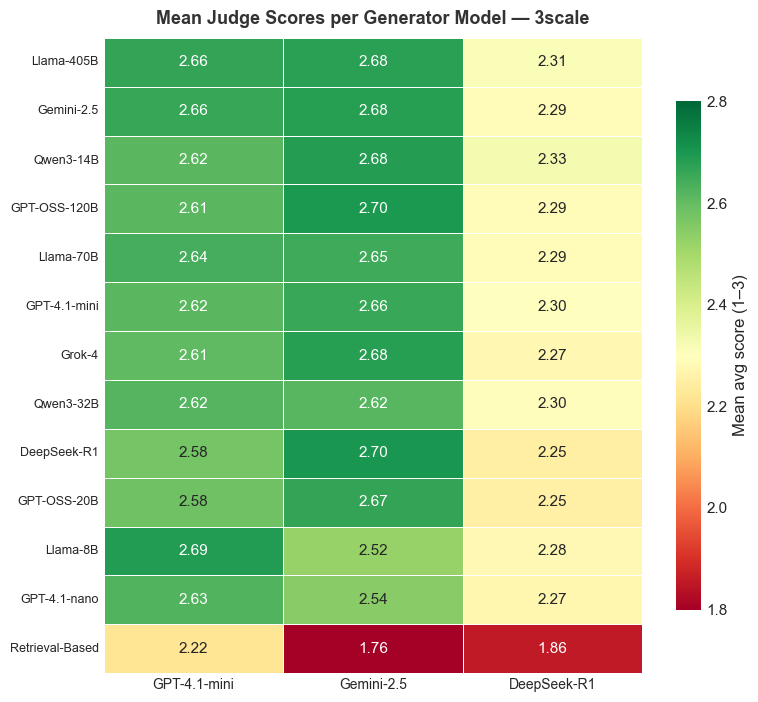

Saved: model_judge_heatmap_3scale.png


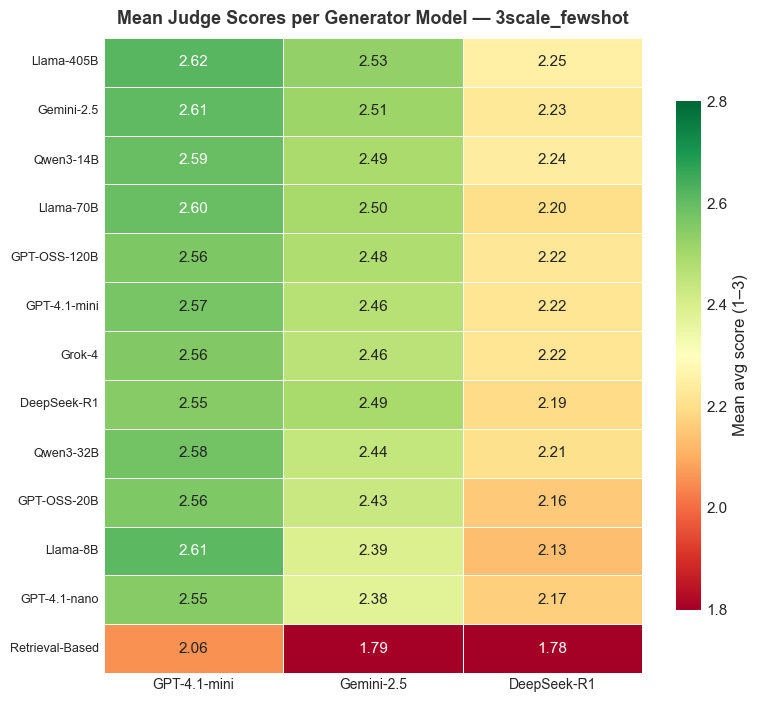

Saved: model_judge_heatmap_fewshot.png


In [202]:

# ============================================================
# CELL 16: Model × Judge Heatmaps
# One heatmap per judge mode (3scale / 3scale_fewshot)
# Rows sorted by consensus mean score descending (best at top)
# ============================================================

def plot_ranking_heatmap(rank_df, title, save_name):
    if rank_df is None or len(rank_df) == 0:
        print(f"[!] No data for {title}. Skipping.")
        return
    rd = rank_df.copy()
    rd['mean_of_means'] = rd[[f'{s}_mean' for s in JUDGE_SHORTS]].mean(axis=1)
    rd = rd.sort_values('mean_of_means', ascending=False)
    matrix = rd[[f'{s}_mean' for s in JUDGE_SHORTS]].values
    col_labels = [JUDGE_FULL_NAMES[s] for s in JUDGE_SHORTS]
    row_labels  = rd['model_label'].tolist()
    n_models = len(rd)

    fig, ax = plt.subplots(figsize=(8, max(5, n_models * 0.55)))
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=1.8, vmax=2.8, ax=ax,
                xticklabels=col_labels, yticklabels=row_labels,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Mean avg score (1–3)', 'shrink': 0.8})
    ax.set_title(title, fontsize=13, fontweight='bold', color=COLORS['text'], pad=10)
    ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticklabels(row_labels, fontsize=9, rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_name}")

plot_ranking_heatmap(ranks_3s,
                     'Mean Judge Scores per Generator Model — 3scale',
                     'model_judge_heatmap_3scale.png')
plot_ranking_heatmap(ranks_fs,
                     'Mean Judge Scores per Generator Model — 3scale_fewshot',
                     'model_judge_heatmap_fewshot.png')


---
## Section 6: Dimension-Level Agreement Breakdown

> **Research question:** Which quality dimension is hardest for judges to agree on — Coherence, Mapping, or Explanatory Power?

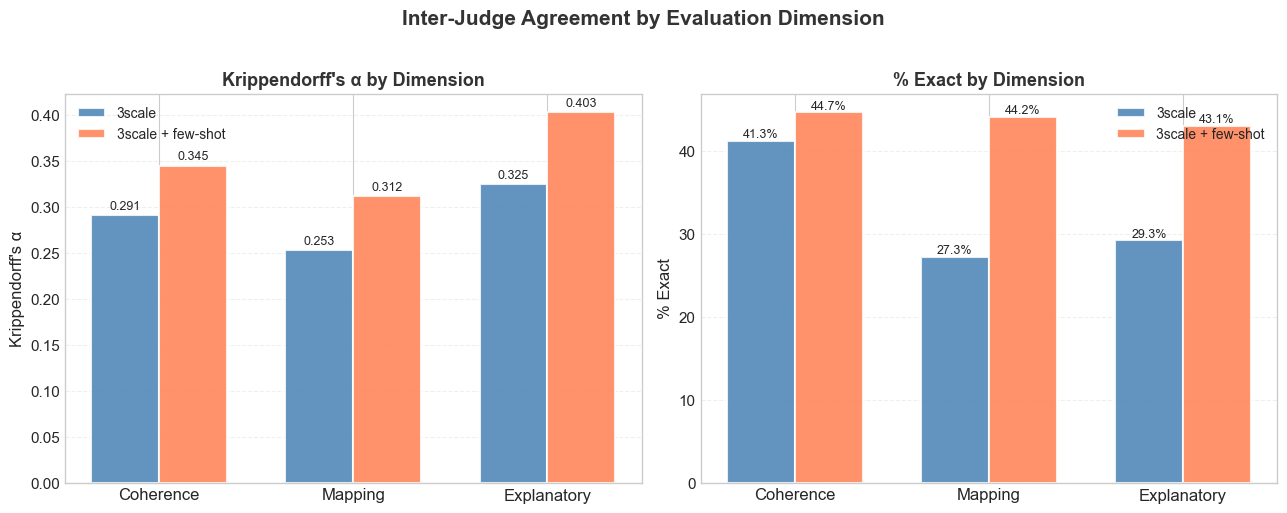

Saved: agreement_by_dimension.png


In [203]:
# ============================================================
# CELL 17: Dimension-Level Agreement Summary
# ============================================================

def plot_dim_agreement(rep_3s, rep_fs, save_name='agreement_by_dimension.png'):
    metrics = ["Krippendorff's α", "% Exact"]
    dim_names = ['Coherence', 'Mapping', 'Explanatory']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    x = np.arange(len(dim_names))
    width = 0.35

    for ax_idx, metric in enumerate(metrics):
        ax = axes[ax_idx]
        vals_3s = [float(rep_3s.loc[d, metric]) for d in dim_names]
        vals_fs = [float(rep_fs.loc[d, metric]) for d in dim_names]

        b1 = ax.bar(x - width/2, vals_3s, width, label='3scale',
                    color=COLORS['primary'],   alpha=0.85, edgecolor='white', linewidth=1.5)
        b2 = ax.bar(x + width/2, vals_fs, width, label='3scale + few-shot',
                    color=COLORS['secondary'], alpha=0.85, edgecolor='white', linewidth=1.5)

        for bars in [b1, b2]:
            for bar in bars:
                h = bar.get_height()
                label_str = f'{h:.3f}' if 'α' in metric else f'{h:.1f}%'
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                        label_str, ha='center', va='bottom', fontsize=9)

        ax.set_xticks(x)
        ax.set_xticklabels(dim_names, fontsize=12)
        ax.set_title(f'{metric} by Dimension', fontweight='bold',
                     fontsize=13, color=COLORS['text'])
        ax.legend(fontsize=10, framealpha=0.9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        unit = '%' if '% Exact' in metric else ''
        ax.set_ylabel(f'{metric}', fontsize=12)

    plt.suptitle('Inter-Judge Agreement by Evaluation Dimension',
                 fontsize=15, fontweight='bold', color=COLORS['text'], y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_name}")

plot_dim_agreement(rep_3s, rep_fs)

---
## Section 7: Agreement by Analogy Type

> **Hypothesis:** Agreement should be higher for `rerank` analogies (more filtered/refined) than `baseline` (raw first output).

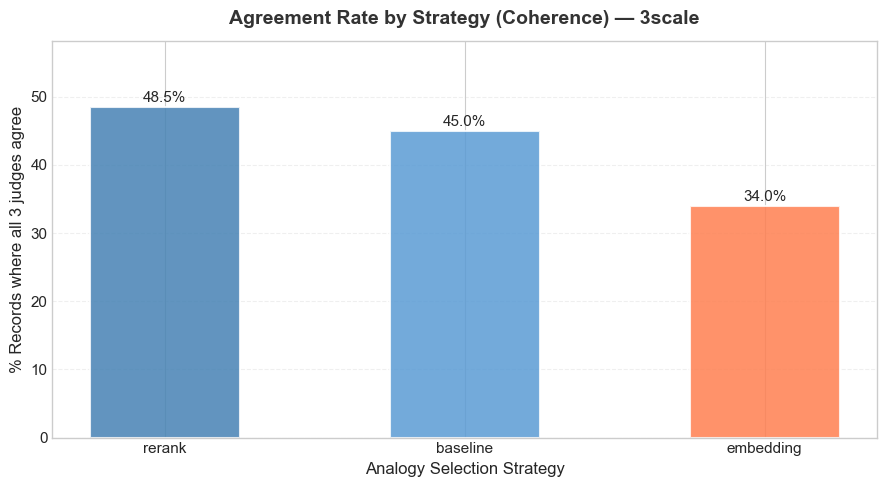

Saved: agreement_by_type_3scale.png


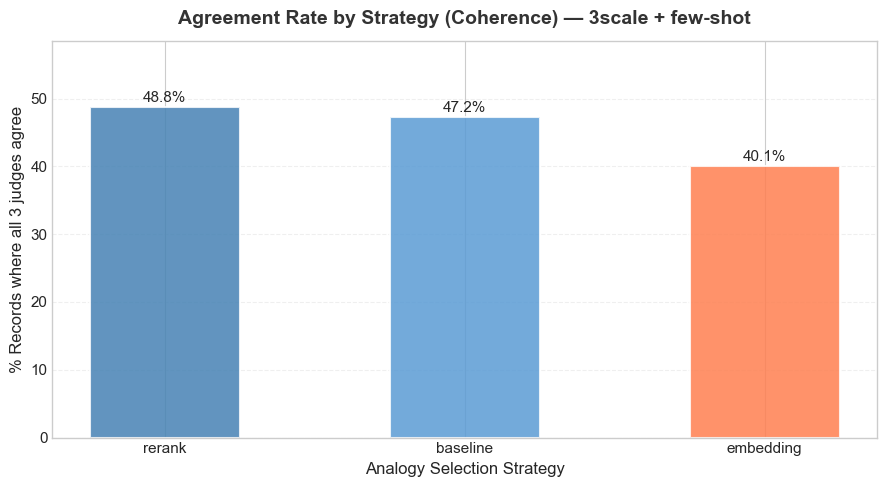

Saved: agreement_by_coh_fewshot.png


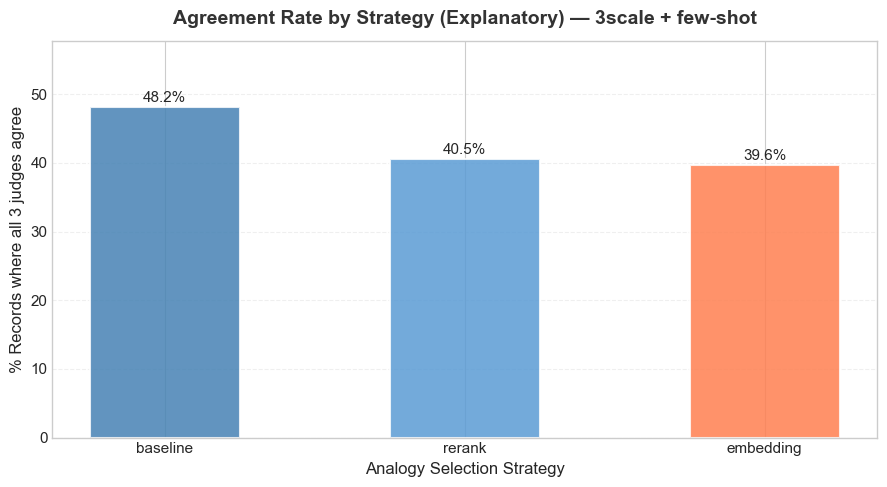

Saved: agreement_by_exp_fewshot.png


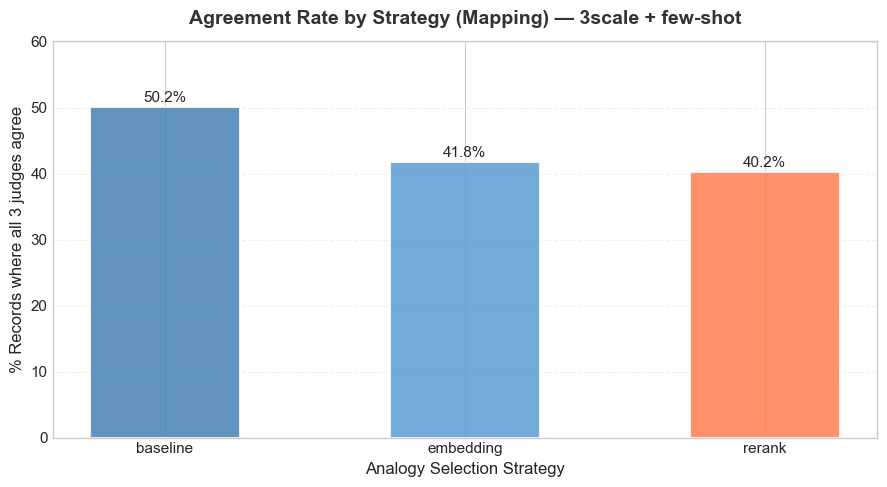

Saved: agreement_by_map_fewshot.png


In [212]:
# ============================================================
# CELL 18: Agreement by Analogy Selection Strategy
# ============================================================

def plot_agreement_by_type(df, mode_label, dim='coh', save_name='agreement_by_type.png'):
    type_counts = df.groupby('analogy_type')[f'agree_{dim}'].apply(
        lambda s: (s == 'all_agree').sum() / len(s) * 100
    ).reset_index()
    type_counts.columns = ['analogy_type', 'pct_all_agree']
    type_counts = type_counts.sort_values('pct_all_agree', ascending=False)

    # Filter to common types (drop very rare ones)
    main_types = ['baseline', 'embedding', 'rerank']
    type_counts_main = type_counts[type_counts['analogy_type'].isin(main_types)]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(type_counts_main['analogy_type'], type_counts_main['pct_all_agree'],
                  color=[COLORS['primary'], COLORS['accent1'], COLORS['secondary']],
                  alpha=0.85, edgecolor='white', linewidth=1.5, width=0.5)

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=11)

    ax.set_xlabel('Analogy Selection Strategy', fontsize=12)
    ax.set_ylabel('% Records where all 3 judges agree', fontsize=12)
    ax.set_title(f'Agreement Rate by Strategy ({DIM_FULL[dim]}) — {mode_label}',
                 fontsize=14, fontweight='bold', color=COLORS['text'], pad=12)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, type_counts_main['pct_all_agree'].max() * 1.2)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_name}")

plot_agreement_by_type(df_3scale,  '3scale',           dim='coh', save_name='agreement_by_type_3scale.png')
plot_agreement_by_type(df_fewshot, '3scale + few-shot', dim='coh', save_name='agreement_by_coh_fewshot.png')
plot_agreement_by_type(df_fewshot, '3scale + few-shot', dim='exp', save_name='agreement_by_exp_fewshot.png')
plot_agreement_by_type(df_fewshot, '3scale + few-shot', dim='map', save_name='agreement_by_map_fewshot.png')

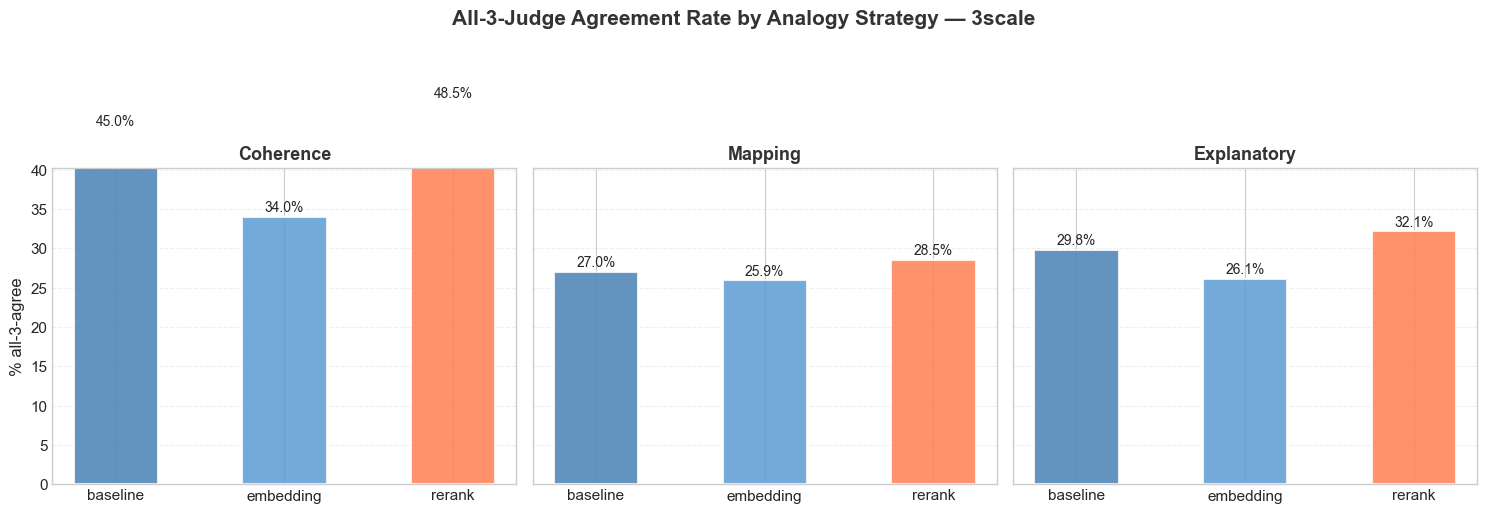

In [205]:
# ============================================================
# CELL 19: Agreement by Type — All Dimensions (3scale)
# ============================================================

main_types = ['baseline', 'embedding', 'rerank']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax_idx, dim in enumerate(DIMENSIONS):
    ax = axes[ax_idx]
    data = []
    for at in main_types:
        sub = df_3scale[df_3scale['analogy_type'] == at]
        pct = (sub[f'agree_{dim}'] == 'all_agree').sum() / len(sub) * 100
        data.append(pct)

    bars = ax.bar(main_types, data,
                  color=[COLORS['primary'], COLORS['accent1'], COLORS['secondary']],
                  alpha=0.85, edgecolor='white', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, data):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

    ax.set_title(DIM_FULL[dim], fontsize=13, fontweight='bold', color=COLORS['text'])
    ax.set_ylabel('% all-3-agree' if ax_idx == 0 else '', fontsize=12)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(data) * 1.25 if max(data) > 0 else 20)

plt.suptitle('All-3-Judge Agreement Rate by Analogy Strategy — 3scale',
             fontsize=15, fontweight='bold', color=COLORS['text'], y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'agreement_by_type_all_dims.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## Section 8: Cross-Mode Comparison Summary (3scale vs 3scale_fewshot)

> **Research question:** Does few-shot calibration improve inter-judge agreement or change the relative model rankings?

In [206]:
# ============================================================
# CELL 20: Side-by-Side Agreement Summary (3scale vs fewshot)
# ============================================================

# Combined metrics table for paper
combined = pd.concat([
    rep_3s.drop(columns=['mode']).add_prefix('3s_'),
    rep_fs.drop(columns=['mode']).add_prefix('fs_'),
], axis=1)

# Show only the key metrics for 3 dimensions
dims_to_show = ['Coherence', 'Mapping', 'Explanatory']
key_metric_3s = "Krippendorff's α"
key_metric_fs = "Krippendorff's α"

print("\n" + "="*80)
print("CROSS-MODE COMPARISON: 3scale vs 3scale_fewshot")
print("="*80)
for dim in dims_to_show:
    a_3s = float(rep_3s.loc[dim, "Krippendorff's α"])
    a_fs = float(rep_fs.loc[dim, "Krippendorff's α"])
    e_3s = float(rep_3s.loc[dim, '% Exact'])
    e_fs = float(rep_fs.loc[dim, '% Exact'])
    delta_a = a_fs - a_3s
    delta_e = e_fs - e_3s
    print(f"  {dim:12s}: α  3scale={a_3s:.3f}  fewshot={a_fs:.3f}  Δ={delta_a:+.3f}")
    print(f"  {' '*12}  %Ex 3scale={e_3s:.1f}%  fewshot={e_fs:.1f}%  Δ={delta_e:+.1f}%")


CROSS-MODE COMPARISON: 3scale vs 3scale_fewshot
  Coherence   : α  3scale=0.291  fewshot=0.345  Δ=+0.054
                %Ex 3scale=41.3%  fewshot=44.7%  Δ=+3.4%
  Mapping     : α  3scale=0.253  fewshot=0.312  Δ=+0.059
                %Ex 3scale=27.3%  fewshot=44.2%  Δ=+16.9%
  Explanatory : α  3scale=0.325  fewshot=0.403  Δ=+0.078
                %Ex 3scale=29.3%  fewshot=43.1%  Δ=+13.8%


In [207]:
# ============================================================
# CELL 21: Cross-Mode Ranking Comparison
# ============================================================
# Does the model ranking change when judges use few-shot prompting?

merge_ranks = ranks_3s[['model_label'] + [f'{s}_rank' for s in JUDGE_SHORTS]].copy()
merge_ranks.columns = ['model_label'] + [f'3s_{s}' for s in JUDGE_SHORTS]

fs_part = ranks_fs[['model_label'] + [f'{s}_rank' for s in JUDGE_SHORTS]].copy()
fs_part.columns = ['model_label'] + [f'fs_{s}' for s in JUDGE_SHORTS]

combined_ranks = merge_ranks.merge(fs_part, on='model_label')
combined_ranks['consensus_rank_3s'] = combined_ranks[[f'3s_{s}' for s in JUDGE_SHORTS]].mean(axis=1)
combined_ranks['consensus_rank_fs'] = combined_ranks[[f'fs_{s}' for s in JUDGE_SHORTS]].mean(axis=1)
combined_ranks = combined_ranks.sort_values('consensus_rank_3s')

print("\nModel ranking comparison: 3scale vs 3scale_fewshot")
print("(consensus rank = mean rank across 3 judges; lower = better)")
print("="*70)
cols_show = ['model_label', 'consensus_rank_3s', 'consensus_rank_fs']
print(combined_ranks[cols_show].to_string(index=False))

# Spearman between 3scale and fewshot consensus rankings
rho, p = stats.spearmanr(
    combined_ranks['consensus_rank_3s'],
    combined_ranks['consensus_rank_fs']
)
print(f"\nSpearman ρ (3scale vs fewshot consensus): {rho:.3f}  (p={p:.4f})")


Model ranking comparison: 3scale vs 3scale_fewshot
(consensus rank = mean rank across 3 judges; lower = better)
    model_label  consensus_rank_3s  consensus_rank_fs
     Llama-405B           3.333333           1.000000
      Qwen3-14B           3.666667           4.000000
     Gemini-2.5           4.000000           2.666667
   GPT-OSS-120B           6.000000           6.000000
   GPT-4.1-mini           6.333333           6.666667
      Llama-70B           6.333333           5.000000
      Qwen3-32B           6.666667           7.333333
       Llama-8B           7.000000           8.333333
         Grok-4           8.000000           7.666667
    DeepSeek-R1           8.333333           8.333333
   GPT-4.1-nano           8.666667          11.000000
    GPT-OSS-20B           9.666667          10.000000
Retrieval-Based          13.000000          13.000000

Spearman ρ (3scale vs fewshot consensus): 0.970  (p=0.0000)


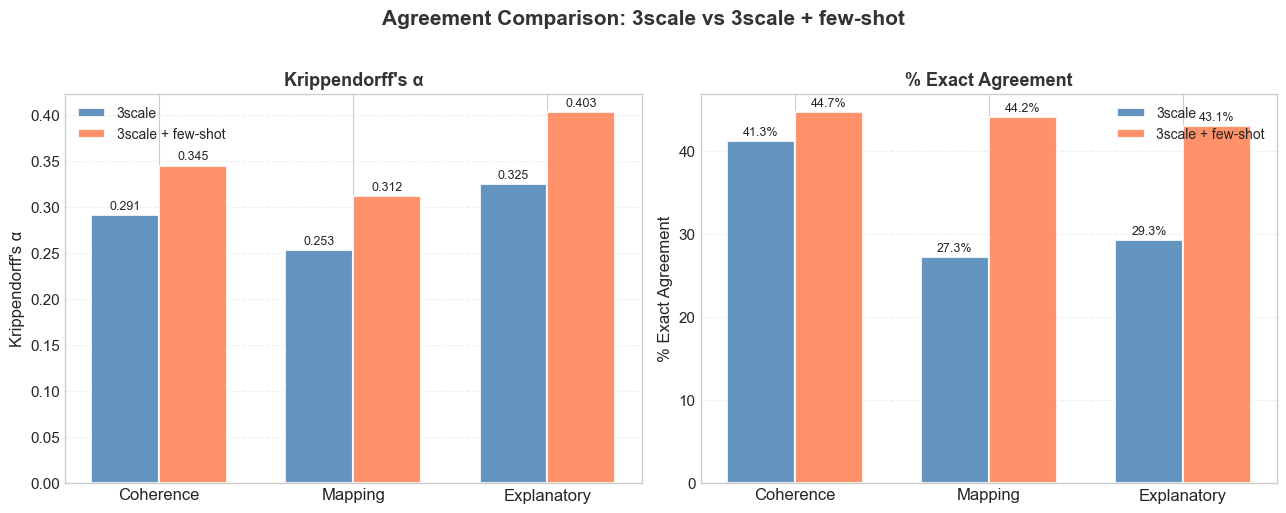

In [208]:
# ============================================================
# CELL 22: Cross-Mode Agreement Plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
dims_plot  = ['Coherence', 'Mapping', 'Explanatory']

# Left: Krippendorff's alpha per dim
ax = axes[0]
alpha_3s = [float(rep_3s.loc[d, "Krippendorff's α"]) for d in dims_plot]
alpha_fs = [float(rep_fs.loc[d, "Krippendorff's α"]) for d in dims_plot]

x = np.arange(len(dims_plot))
width = 0.35
b1 = ax.bar(x - width/2, alpha_3s, width, label='3scale',
            color=COLORS['primary'],   alpha=0.85, edgecolor='white', linewidth=1.5)
b2 = ax.bar(x + width/2, alpha_fs, width, label='3scale + few-shot',
            color=COLORS['secondary'], alpha=0.85, edgecolor='white', linewidth=1.5)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(dims_plot, fontsize=12)
ax.set_ylabel("Krippendorff's α", fontsize=12)
ax.set_title("Krippendorff's α", fontsize=13, fontweight='bold', color=COLORS['text'])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Right: % Exact agreement per dim
ax = axes[1]
exact_3s = [float(rep_3s.loc[d, '% Exact']) for d in dims_plot]
exact_fs = [float(rep_fs.loc[d, '% Exact']) for d in dims_plot]

b1 = ax.bar(x - width/2, exact_3s, width, label='3scale',
            color=COLORS['primary'],   alpha=0.85, edgecolor='white', linewidth=1.5)
b2 = ax.bar(x + width/2, exact_fs, width, label='3scale + few-shot',
            color=COLORS['secondary'], alpha=0.85, edgecolor='white', linewidth=1.5)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(dims_plot, fontsize=12)
ax.set_ylabel('% Exact Agreement', fontsize=12)
ax.set_title('% Exact Agreement', fontsize=13, fontweight='bold', color=COLORS['text'])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Agreement Comparison: 3scale vs 3scale + few-shot',
             fontsize=15, fontweight='bold', color=COLORS['text'], y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_mode_agreement_comparison.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## Summary & Key Findings

This cell prints a concise summary of all key results.

In [209]:
# ============================================================
# CELL 23: Summary of Key Findings
# ============================================================

print("="*70)
print("SUMMARY: LLM Judge Agreement Analysis")
print("="*70)

for mode_label, rep, df in [('3scale', rep_3s, df_3scale), ('3scale_fewshot', rep_fs, df_fewshot)]:
    print(f"\n[{mode_label}]  N = {len(df):,} records")
    print(f"  Krippendorff's alpha:")
    for dim in ['Coherence', 'Mapping', 'Explanatory']:
        val = float(rep.loc[dim, ALPHA_KEY])
        print(f"    {dim:12s}: {val:.3f}")

    print(f"  % Exact agreement:")
    for dim in ['Coherence', 'Mapping', 'Explanatory']:
        val = float(rep.loc[dim, '% Exact'])
        print(f"    {dim:12s}: {val:.1f}%")

    all_agree_pct = df['agree_all_dims'].mean() * 100
    print(f"  Full agreement (all 3 dims): {all_agree_pct:.1f}%")

print("\n" + "="*70)
print("Figures saved to:", OUTPUT_DIR)

SUMMARY: LLM Judge Agreement Analysis

[3scale]  N = 25,158 records
  Krippendorff's alpha:
    Coherence   : 0.291
    Mapping     : 0.253
    Explanatory : 0.325
  % Exact agreement:
    Coherence   : 41.3%
    Mapping     : 27.3%
    Explanatory : 29.3%
  Full agreement (all 3 dims): 13.4%

[3scale_fewshot]  N = 25,159 records
  Krippendorff's alpha:
    Coherence   : 0.345
    Mapping     : 0.312
    Explanatory : 0.403
  % Exact agreement:
    Coherence   : 44.7%
    Mapping     : 44.2%
    Explanatory : 43.1%
  Full agreement (all 3 dims): 16.4%

Figures saved to: ..\results\judge_analysis
